# 4. Linear Regression

:::{admonition} Course Website 
http://54.243.252.9/ce-5319-webroot/ 
:::

Imagine you're trying to forecast the future — whether it’s the price of a home, tomorrow’s temperature, or how much rain will fall during a storm. What you're really doing is predicting an unknown outcome based on known inputs. This process is at the heart of what we call a prediction engine — a tool that takes past patterns and applies them to make informed guesses about the future.

In the world of data science and machine learning, building a prediction engine means finding a relationship between the inputs (like square footage, time of day, or cloud cover) and the output we want to estimate. The stronger and clearer that relationship is, the better our prediction will be.

One of the simplest — and most powerful — ways to build a prediction engine is with something called linear regression.

## What is Linear Regression?
Linear regression **assumes** that there is a straight-line relationship between what we observe (the input, feature, or “independent variable”) and what we’re trying to predict (the output, response, or “dependent variable”). If you can imagine drawing a best-fit line through a cloud of data points, that line is your model — your prediction engine in its most basic form.

The mathematical idea is simple:

$$ \text{Predicted Output}=\text{slope}×\text{Input}+\text{intercept}$$

This line summarizes how the output changes as the input changes. For example:

Want to predict runoff from rainfall? Use regression to relate rainfall depth (input) to observed runoff (output).

Want to estimate the strength of a concrete mix? Use regression to relate ingredients and curing time to strength.

## Why It Matters in Machine Learning
Linear regression is more than just a tool for plotting lines — it’s a gateway to machine learning. It teaches us how to:

- Learn from data

- Minimize error

- Generalize patterns for new, unseen inputs

Many modern machine learning models — including neural networks and decision trees — extend the core logic of regression: find the best rule to map input to output.

# Readings/References

1. [Burkov, A. (2019) The One Hundred Page Machine Learning Book pp 21-25](http://ema.cri-info.cm/wp-content/uploads/2019/07/2019BurkovTheHundred-pageMachineLearning.pdf) 

2. [Rashid, Tariq. (2016) Make Your Own Neural Network. Kindle Edition. ](https://www.goodreads.com/en/book/show/29746976-make-your-own-neural-network)

3. [Chan, Jamie. Machine Learning With Python For Beginners: A Step-By-Step Guide with Hands-On Projects (Learn Coding Fast with Hands-On Project Book 7) (p. 106-118). Kindle Edition.](https://www.amazon.com/Machine-Learning-Python-Beginners-Hands-ebook/dp/B09BNYDH5F/ref=sr_1_1?crid=2AWC6H5O8OTXX&dib=eyJ2IjoiMSJ9.lb1DU4Hg5eM1dTpip0RqZQ.FB7zPx86H30WvSkCwGQrxSos7pXT20BjOeJwlfa0m78&dib_tag=se&keywords=Chan%2C+Jamie.+Machine+Learning+With+Python+For+Beginners%3A+A+Step-By-Step+Guide+with+Hands-On+Projects+%28Learn+Coding+Fast+with+Hands-On+Project+Book+7%29&qid=1741388116&sprefix=%2Caps%2C465&sr=8-1)

4. Chan, Jamie. Machine Learning With Python For Beginners: A Step-By-Step Guide with Hands-On Projects (Learn Coding Fast with Hands-On Project Book 7) (p. 2). Kindle Edition.

5. [Anthony V. Fiacco, Garth P. McCormick, John M. Danskin, Jr.,(1967). The Sequential Unconstrained Minimization Technique (SUMT) without Parameters, Operations Research, Vol. 15, No. 5 (Sep. - Oct., 1967), pp. 820-829](ce-5319-webroot/3-Readings/Fiacco-SequentialUnconstrainedMinimization-1967.pdf)

6. "Linear Regression in Python"__ by __Sadrach Pierre__ available at* https://towardsdatascience.com/linear-regression-in-python-a1d8c13f3242 <br>
7. "Introduction to Linear Regression in Python"__ available at* https://cmdlinetips.com/2019/09/introduction-to-linear-regression-in-python/ <br>
8. "Linear Regression in Python"__ by __Mirko Stojiljković__ available at* https://realpython.com/linear-regression-in-python/ <br>
9.  [https://inferentialthinking.com/chapters/15/Prediction.html](https://inferentialthinking.com/chapters/15/Prediction.html)<br>
10. [Weighted Least Squares (Wikipedia)](https://en.wikipedia.org/wiki/Weighted_least_squares)



## Videos

1. ["StatQuest: Fitting a line to data, aka least squares, aka linear regression."__ by __StatQuest with Josh Starmer__ *YouTube*](https://www.youtube.com/watch?v=PaFPbb66DxQ&list=PLblh5JKOoLUIzaEkCLIUxQFjPIlapw8nU) <br>
2. ["Statistics 101: Linear Regression, The Very Basics"__ by __Brandon Foltz__ *YouTube*](https://www.youtube.com/watch?v=ZkjP5RJLQF4) <br>
31. ["How to Build a Linear Regression Model in Python | Part 1" and 2,3,4!__ by __Sigma Coding__*YouTube*](https://www.youtube.com/watch?v=MRm5sBfdBBQ) <br>


In [121]:
import warnings
warnings.filterwarnings('ignore')


## Prediction Engines

This section examines the process of prediction, or forecasting if you will.  In prediction we are attempting to build an excitation-response model so that when new (future) excitations are supplied to the model, the new (future) responses are predicted.  

As an example, suppose a 1 Newton force is applied to a 1 kilogram object, we expect an acceleration of 1 meter per second per second.  The inputs are mass and force, the response is acceleration.  Now if we triple the mass, and leave the force unchanged then the acceleration is predicted to be 1/3 meter per second per second.  The prediction machine structure in this example could be something like

$$a=\beta_1 F^{\beta_2} \cdot \beta_3 m^{\beta_4}$$

After training the fitted (learned) model would determine that $\beta_1=\beta_2=\beta_3=1$ and $\beta_4=-1$ is the best performing model and that would be our prediction engine.  

Or we could just trust Newton that the prediction model is

$$a=\frac{F}{m}$$

## A Simple Prediction Machine

Imagine a basic machine that takes a question, does some “thinking” and pushes out an answer. 
Here’s a diagram of the process: 

![](eat-sleep-poop1.png)

Computers don’t really think, they’re just fast calculators (actually difference engines, but that's for another time), so let’s use more appropriate words to describe what’s going on: 

![](eat-sleep-poop2.png)

A computer takes some input, does some calculation and poops out an output. The following illustrates this. An input of “3 x 4” is processed, perhaps by turning multiplication into an easier set of additions, and the output answer “12” poops out.

![](three-by-four.png)

Not particularly impressive - we could even write a function!

In [122]:
def threeByfour(a,b):
    value = a * b
    return(value)

a = 3; b=4

print('a times b =',threeByfour(a,b))

a times b = 12


Next, Imagine a machine that converts kilometres to miles, like the following:

![](km-2-miles.png)

:::{admonition} Suspended Assumptions: Entering the Domain of Pattern-Seeking
But imagine we don’t know the formula for converting between kilometres and miles. All we know is the the relationship between the two is **linear**. That means if we double the number in miles, the same distance in kilometres is also doubled. 
:::

This linear relationship between kilometres and miles gives us a clue about that mysterious calculation; it needs to be of the form “miles = kilometres x **c**”, where **c** is a constant. We don’t know what this constant **c** is yet. The only other clues we have are some examples pairing kilometres with the correct value for miles. These are like real world observations used to test scientific theories - they’re examples of real world truth. 

|Truth Example|Kilometres|Miles|
|:---|---:|---:|
|1| 0| 0| 
|2| 100| 62.137|

To work out that missing constant **c**  in a pattern matching domain one just picks a value at random and gives it a try! Let’s try **c** = 0.5 and see what happens.

![](first-shot.png)

Here we have miles = kilometres x **c**, where kilometres is 100 and **c** is our current guess at 0.5. That gives 50 miles. Okay. That’s not bad at all given we chose **c** = 0.5 at random! But we know it’s not exactly right because our truth example number 2 tells us the answer should be 62.137. We’re wrong by 12.137. That’s the **error**, the difference between our calculated answer and the actual truth from our list of examples. That is, 

error = truth - calculated = 62.137 - 50 = 12.137



In [123]:
def km2miles(km,c):
    value = km*c
    return(value)

x=100
c=0.5
y=km2miles(x,c)
t=62.137

print(x, 'kilometers is estimated to be ',y,' miles')
print('Estimation error is ', t-y , 'miles')

100 kilometers is estimated to be  50.0  miles
Estimation error is  12.137 miles


![](first-error.png)

So what next? We know we’re wrong, and by how much. Instead of being a reason to despair, we use this error to guide a second, better, guess at **c**. Look at that error again. We were short by 12.137. Because the formula for converting kilometres to miles is linear, miles = kilometres x **c**, we know that increasing **c** will increase the output. Let’s nudge **c** up from 0.5 to 0.6 and see what happens. 

:::{note}
Recall the three parts of a ML algorithm (for the learning phase):
1. a function to assess the quality of a prediction or classification. Typically a loss function which we want to minimize, or a likelihood function which we want to maximize. It goes by many names: objective, cost, loss, merit are common names for this function.
2. an objective criterion (a goal) based on the loss function (maximize or minimize), and
3. an optimization routine that uses the training data to find a solution to the optimization problem posed by the objective criterion.

In the current example, the "Estimation error" is our quality function, making that error small is the "goal" (objective); what remains is a way to use the data (admittedly quite sparse) to find a solution to minimizing the error.
:::

![](second-shot.png)

With **c** now set to 0.6, we get miles = kilometres x **c** = 100 x 0.6 = 60. That’s better than the previous answer of 50. We’re clearly making progress! Now the error is a much smaller 2.137. It might even be an error we’re happy to live with.

In [124]:
def km2miles(km,c):
    value = km*c
    return(value)

x=100
c=0.6
y=km2miles(x,c)
t=62.137

print(x, 'kilometers is estimated to be ',y,' miles')
print('Estimation error is ', t-y , 'miles')

100 kilometers is estimated to be  60.0  miles
Estimation error is  2.1370000000000005 miles


The important point here is that we used the error to guide how we nudged the value of c. We wanted to increase the output from 50 so we increased **c** a little bit. Rather than try to use algebra to work out the exact amount **c** needs to change, let’s continue with this approach of refining **c**. If you’re not convinced, and think it’s easy enough to work out the exact answer, remember that many more interesting problems won’t have simple mathematical formulas relating the output and input. That’s why we use "machine learning" methods. Let’s do this again. The output of 60 is still too small. Let’s nudge the value of **c** up again from 0.6 to 0.7.

In [125]:
def km2miles(km,c):
    value = km*c
    return(value)

x=100
c=0.7
y=km2miles(x,c)
t=62.137

print(x, 'kilometers is estimated to be ',y,' miles')
print('Estimation error is ', t-y , 'miles')

100 kilometers is estimated to be  70.0  miles
Estimation error is  -7.8629999999999995 miles


![](http://54.243.252.9/ce-5319-webroot/ce5319jb/lessons/lesson3/overshoot.png)

Oh no! We’ve gone too far and **overshot** the known correct answer. Our previous error was 2.137 but now it’s -7.863. The minus sign simply says we overshot rather than undershot, remember the error is (correct value - calculated value). Ok so **c** = 0.6 was way better than c = 0.7. We could be happy with the small error from **c** = 0.6 and end this exercise now. But let’s go on for just a bit longer. 

Let's split the difference from our last guess - we still have overshot, but not as much (-2.8629).  
Split again to **c**=0.625, and overshoot is only (-0.3629) (we could sucessively split the **c** values until we are close enough. The method just illustrated is called bisection, and the important point is that we avoided any mathematics other than bigger/smaller and multiplication and subtraction; hence just arithmetic.)

That’s much much better than before. We have an output value of 62.5 which is only wrong by 0.3629 from the correct 62.137. So that last effort taught us that we should moderate how much we nudge the value of **c**. If the outputs are getting close to the correct answer - that is, the error is getting smaller - then don’t nudge the constant so much. That way we avoid overshooting the right value, like we did earlier. Again without getting too distracted by exact ways of working out **c**, and to remain focussed on this idea of successively refining it, we could suggest that the correction is a fraction of the error. That’s intuitively right - a big error means a bigger correction is needed, and a tiny error means we need the teeniest of nudges to **c**. What we’ve just done, believe it or not, is walked through the very core process of learning in a neural network - we’ve trained the machine to get better and better at giving the right answer. It is worth pausing to reflect on that - we’ve not solved a problem exactly in one step. Instead, we’ve taken a very different approach by trying an answer and improving it repeatedly. Some use the term **iterative** and it means repeatedly improving an answer bit by bit.


In [126]:
def km2miles(km,c):
    value = km*c
    return(value)

x=100
c=0.65
y=km2miles(x,c)
t=62.137

print(x, 'kilometers is estimated to be ',y,' miles')
print('Estimation error is ', t-y , 'miles')

100 kilometers is estimated to be  65.0  miles
Estimation error is  -2.8629999999999995 miles


In [127]:
def km2miles(km,c):
    value = km*c
    return(value)

x=100
c=0.625
y=km2miles(x,c)
t=62.137

print(x, 'kilometers is estimated to be ',y,' miles')
print('Estimation error is ', t-y , 'miles')

100 kilometers is estimated to be  62.5  miles
Estimation error is  -0.36299999999999955 miles


Now let's automate the process.

We have our prediction engine structure embedded into the `km2miles()` function.  We have a database of observations (albeit its kind of small). We need to find a value of `c` that's good enough then we can use the prediction engine to convert new values.  As stated above bisection seems appropriate, so here we will adapt a classical bisection algorithm for our machine.

:::{note}
The code below is shamelessly lifted from [Qingkai Kong, Timmy Siauw, Alexandre M. Bayen, 2021 Python Programming and Numerical Methods, Academic Press](https://pythonnumericalmethods.berkeley.edu/notebooks/Index.html) and adapted explicitly for the machine described herein.  If you go to the source the authors use **lambda** objects to generalize their scripts, but I choose to simply break their fine programming structure for my needs; something everyone should get comfortable with.
:::

In [128]:
def km2miles(km,c):
    value = km*c
    return(value)

howmany = 50 # number of iterations
clow = 0 # lower limit for c
chigh = 1 # upper limit for c
x=100 # ground truth value
dtrue = 62.137 # ground truth value
tol = 1e-6 # desired accuracy

import numpy # useful library with absolute value and sign functions

############ Learning Phase ################
# check if clow and chigh bound a solution
if numpy.sign(km2miles(x,clow)-dtrue) == numpy.sign(km2miles(x,chigh)-dtrue):
    raise Exception("The scalars clow and chigh do not bound a solution")


for iteration in range(howmany):         
# get midpoint
    m = (clow + chigh)/2

    if numpy.abs(km2miles(x,clow)-dtrue) < tol:
        # stopping condition, report m as root
        print('Normal Exit Learning Complete')
        break
    elif numpy.sign(km2miles(x,clow)-dtrue) == numpy.sign(km2miles(x,m)-dtrue):
        # case where m is an improvement on a. 
        # Make recursive call with a = m
        clow = m # update a with m
    elif numpy.sign(km2miles(x,chigh)-dtrue) == numpy.sign(km2miles(x,m)-dtrue):
        # case where m is an improvement on b. 
        # Make recursive call with b = m
        chigh = m # update b with m
####################################################

Normal Exit Learning Complete


In [129]:
############# Testing Phase ########################
y=km2miles(x,m)
print('number trials',iteration)
print('model c value',m)
print(x,'kilometers is estimated to be ',round(y,3),' miles')
print('Estimation error is ', round(dtrue-y,3) , 'miles')
print('Testing Complete')

number trials 27
model c value 0.6213699989020824
100 kilometers is estimated to be  62.137  miles
Estimation error is  0.0 miles
Testing Complete


In [130]:
############ Deployment Phase #######################
xx = 1000
y=km2miles(xx,m)
print(xx,'kilometers is estimated to be ',round(y,3),' miles')

1000 kilometers is estimated to be  621.37  miles


Moving beyond our simple model, let's extend `km2miles(`) into a proper linear model with both a slope (c) and intercept, then modify the search engine to adjust both parameters.

However, since the current code only searches for a single parameter (c) via bisection, we'll treat the task as:

Still using bisection (so we can only vary one parameter at a time)

But generalize the model to:

$$ \text{miles}=c * \text{km}+\text{intercept} $$

Adjusting the function and allowing a fixed intercept the modified script is:

In [131]:
import numpy as np

# Define linear model
def km2miles(km, c, intercept):
    return km * c + intercept

# Define squared error loss
def loss(km, c, intercept, dtrue):
    y_pred = km2miles(km, c, intercept)
    return (y_pred - dtrue) ** 2

# Bisection search to minimize error by adjusting a single parameter
def bisection_optimize(param_range, fixed_other_param, km, dtrue, is_slope, tol=1e-6, max_iter=50):
    low, high = param_range
    for _ in range(max_iter):
        mid = (low + high) / 2

        if is_slope:
            err_low = loss(km, low, fixed_other_param, dtrue)
            err_mid = loss(km, mid, fixed_other_param, dtrue)
        else:
            err_low = loss(km, fixed_other_param, low, dtrue)
            err_mid = loss(km, fixed_other_param, mid, dtrue)

        if np.abs(err_mid - err_low) < tol:
            return mid

        if err_mid > err_low:
            high = mid
        else:
            low = mid
    return (low + high) / 2

# Coordinate-wise search wrapper
def coordinate_descent_linear(km, dtrue, c_range, intercept_range, tol=1e-6, outer_iters=10):
    c = 0.0
    intercept = 0.0

    for step in range(outer_iters):
        # Step 1: Fix intercept, optimize slope
        c = bisection_optimize(c_range, intercept, km, dtrue, is_slope=True, tol=tol)

        # Step 2: Fix slope, optimize intercept
        intercept = bisection_optimize(intercept_range, c, km, dtrue, is_slope=False, tol=tol)

        print(f"Step {step+1}: slope = {c:.6f}, intercept = {intercept:.6f}, loss = {loss(km, c, intercept, dtrue):.6e}")

    return c, intercept

In [132]:
# Example problem: match 100 km to 62.137 miles
km = 100
dtrue = 62.137

# Initial search bounds
c_range = (0, 1)
intercept_range = (-10, 10)

# Run coordinate descent
best_c, best_intercept = coordinate_descent_linear(km, dtrue, c_range, intercept_range)
print(f"\n✅ Final Model: y = {best_c:.6f} * x + {best_intercept:.6f}")


Step 1: slope = 0.625000, intercept = 0.000001, loss = 1.317704e-01
Step 2: slope = 0.625000, intercept = 0.000001, loss = 1.317704e-01
Step 3: slope = 0.625000, intercept = 0.000001, loss = 1.317704e-01
Step 4: slope = 0.625000, intercept = 0.000001, loss = 1.317704e-01
Step 5: slope = 0.625000, intercept = 0.000001, loss = 1.317704e-01
Step 6: slope = 0.625000, intercept = 0.000001, loss = 1.317704e-01
Step 7: slope = 0.625000, intercept = 0.000001, loss = 1.317704e-01
Step 8: slope = 0.625000, intercept = 0.000001, loss = 1.317704e-01
Step 9: slope = 0.625000, intercept = 0.000001, loss = 1.317704e-01
Step 10: slope = 0.625000, intercept = 0.000001, loss = 1.317704e-01

✅ Final Model: y = 0.625000 * x + 0.000001


:::{note}
At its core, machine learning is about building a rule that turns inputs into outputs as accurately as possible. Here, we’ve chosen one of the simplest forms of that rule: a straight line. Our "learning algorithm" is nothing more than an intelligent guess-and-check process, tuning the slope and intercept to reduce the prediction error. It’s not AI magic — it’s coordinate-wise bisection.
:::

And now with minimal further modifications, we can handle a set of observations instead of single (one shot) cases.

In [133]:
import numpy as np
import matplotlib.pyplot as plt

# Linear model
def km2miles(x, c, intercept):
    return c * x + intercept

# Mean squared error loss across all data points
def mse_loss(x_vals, y_true, c, intercept):
    y_pred = km2miles(x_vals, c, intercept)
    return np.mean((y_pred - y_true) ** 2)

# Bisection optimizer for one variable (slope or intercept)
def bisection_optimize(param_range, fixed_other_param, x_vals, y_true, is_slope, tol=1e-6, max_iter=50):
    low, high = param_range
    for _ in range(max_iter):
        mid = (low + high) / 2

        if is_slope:
            err_low = mse_loss(x_vals, y_true, low, fixed_other_param)
            err_mid = mse_loss(x_vals, y_true, mid, fixed_other_param)
        else:
            err_low = mse_loss(x_vals, y_true, fixed_other_param, low)
            err_mid = mse_loss(x_vals, y_true, fixed_other_param, mid)

        if np.abs(err_mid - err_low) < tol:
            return mid

        if err_mid > err_low:
            high = mid
        else:
            low = mid
    return (low + high) / 2

# Coordinate-wise optimizer for slope and intercept
def coordinate_descent_linear(x_vals, y_true, c_range, intercept_range, tol=1e-6, outer_iters=10):
    c = 0.0
    intercept = 0.0

    for step in range(outer_iters):
        c = bisection_optimize(c_range, intercept, x_vals, y_true, is_slope=True, tol=tol)
        intercept = bisection_optimize(intercept_range, c, x_vals, y_true, is_slope=False, tol=tol)
        print(f"Step {step+1}: slope = {c:.6f}, intercept = {intercept:.6f}, MSE = {mse_loss(x_vals, y_true, c, intercept):.6e}")

    return c, intercept

# Plotting function
def plot_regression(x_vals, y_true, c, intercept):
    x_plot = np.linspace(min(x_vals), max(x_vals), 100)
    y_pred = km2miles(x_plot, c, intercept)

    plt.scatter(x_vals, y_true, color='blue', label='Observed Data')
    plt.plot(x_plot, y_pred, color='red', label=f'Best-Fit Line\ny = {c:.3f}x + {intercept:.3f}')
    plt.title("Linear Regression Fit via Coordinate-wise Bisection")
    plt.xlabel("x (e.g., km)")
    plt.ylabel("y (e.g., miles)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


Step 1: slope = 0.625000, intercept = 0.000001, MSE = 1.480059e-01
Step 2: slope = 0.625000, intercept = 0.000001, MSE = 1.480059e-01
Step 3: slope = 0.625000, intercept = 0.000001, MSE = 1.480059e-01
Step 4: slope = 0.625000, intercept = 0.000001, MSE = 1.480059e-01
Step 5: slope = 0.625000, intercept = 0.000001, MSE = 1.480059e-01
Step 6: slope = 0.625000, intercept = 0.000001, MSE = 1.480059e-01
Step 7: slope = 0.625000, intercept = 0.000001, MSE = 1.480059e-01
Step 8: slope = 0.625000, intercept = 0.000001, MSE = 1.480059e-01
Step 9: slope = 0.625000, intercept = 0.000001, MSE = 1.480059e-01
Step 10: slope = 0.625000, intercept = 0.000001, MSE = 1.480059e-01


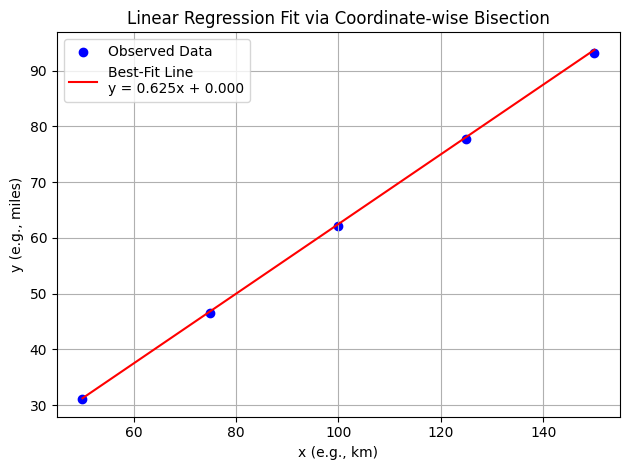

In [134]:
# Sample training data
x_data = np.array([50, 75, 100, 125, 150])
y_data = np.array([31.068, 46.603, 62.137, 77.672, 93.206])  # approx. km → miles

# Search ranges
c_bounds = (0.5, 1.0)
intercept_bounds = (-10, 10)

# Fit model
best_c, best_intercept = coordinate_descent_linear(x_data, y_data, c_bounds, intercept_bounds)

# Plot
plot_regression(x_data, y_data, best_c, best_intercept)

Now with somewhat arbitrary data 

:::{warning}
The algorithm as presented is quite unstable, so still takes some interaction from the human, but the idea is sound; ML is just arithmetic in some sense.  The technique being employed is a variation of [Sequential Unconstrained Minimization Technique (SUMT)](http://54.243.252.9/ce-5319-webroot/3-Readings/Fiacco-SequentialUnconstrainedMinimization-1967.pdf)
:::

Step 1: slope = 3.390625, intercept = 4.650000, MSE = 6.302154e+00
Step 2: slope = 3.281250, intercept = 4.650000, MSE = 6.236475e+00
Step 3: slope = 3.281250, intercept = 4.650000, MSE = 6.236475e+00
Step 4: slope = 3.281250, intercept = 4.650000, MSE = 6.236475e+00
Step 5: slope = 3.281250, intercept = 4.650000, MSE = 6.236475e+00
Step 6: slope = 3.281250, intercept = 4.650000, MSE = 6.236475e+00
Step 7: slope = 3.281250, intercept = 4.650000, MSE = 6.236475e+00
Step 8: slope = 3.281250, intercept = 4.650000, MSE = 6.236475e+00
Step 9: slope = 3.281250, intercept = 4.650000, MSE = 6.236475e+00
Step 10: slope = 3.281250, intercept = 4.650000, MSE = 6.236475e+00


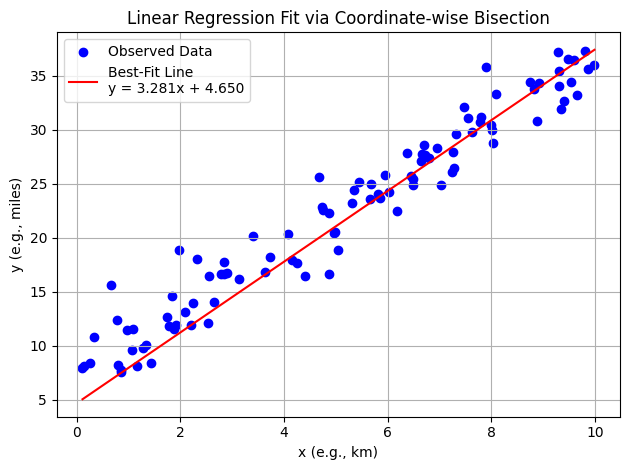

In [135]:
# Generate synthetic dataset
np.random.seed(75)
X = np.random.rand(100, 1) * 10  # Feature: Random values between 0 and 10
Y = 3 * X + 7 + np.random.randn(100, 1) * 2  # Target: Linear function with noise

# Search ranges
c_bounds = (0, 3.5)
intercept_bounds = (0.6, 6)
outer_iters = 10

# Fit model
best_c, best_intercept = coordinate_descent_linear(X, Y, c_bounds, intercept_bounds, outer_iters)

# Plot
plot_regression(X, Y, best_c, best_intercept)

## Mapping Machine Learning Components in Our Example
:::{note}
Recall the three parts of a machine learning algorithm (during the learning phase):

A function to assess the quality of a prediction or classification — typically a loss function we want to minimize, or a likelihood function we want to maximize. It may be called an objective, cost, loss, or merit function.

An objective criterion (a goal) based on the loss function — usually to minimize or maximize it.

An optimization routine that uses training data to find a solution to the optimization problem posed by the objective criterion.

In the current example, the "Estimation error" is our quality function, minimizing that error is the goal, and the coordinate-wise bisection routine is the optimization strategy.
:::

### 1. Quality Function: Mean Squared Error
This function measures how far off the model’s predictions are from the observed data — our loss function.

```python
def mse_loss(x_vals, y_true, c, intercept):
    y_pred = km2miles(x_vals, c, intercept)
    return np.mean((y_pred - y_true) ** 2)
```

### 2. Objective Criterion: Minimize Error
We define our learning goal as minimizing the MSE. The algorithm seeks values of c and intercept that produce the lowest possible error.

```python
if np.abs(err_mid - err_low) < tol:
    return mid
```

This expression represents the stopping condition for our optimization. Once the error improvement between steps is small enough, we accept the current value.

### 3. Optimization Routine: Coordinate-wise Bisection
This is our search engine: an algorithm that adjusts one parameter at a time to reduce error, alternating between slope and intercept.

```python
def bisection_optimize(param_range, fixed_other_param, x_vals, y_true, is_slope, tol=1e-6, max_iter=50):
    ...
```
And the outer loop controlling the process:

```python
def coordinate_descent_linear(x_vals, y_true, c_range, intercept_range, tol=1e-6, outer_iters=10):
    ...
```
Together, these act as a simple machine learning engine: searching parameter space using training data to reduce loss and improve predictions.

### What Are We Minimizing?

Every machine learning algorithm is defined by its loss function — a way of measuring how wrong a prediction is. Here, we’re minimizing the mean squared error (MSE), which rewards small mistakes and punishes large ones. The model improves not because it "understands" — but because it "searches better."

### Why Coordinate Descent?
Why don’t we just jump straight to a solution? Because we rarely know what the best answer looks like. Instead, we simplify the problem: hold one variable still while adjusting the other. This stepwise tuning, known as coordinate descent, is a bridge between intuition and computation — a introduction-friendly form of optimization.

### A Gentle Intro to Learning
With just a handful of data points and a basic search method, we’ve constructed a working prediction engine. This model can now estimate outputs for new inputs — and that’s the essence of learning. Every powerful ML algorithm, from linear regression to neural networks, follows this basic structure:

- Pick a model structure
- Measure its performance
- Adjust parameters to improve
- Repeat until good enough

# 4.1 What is Regression

A **systematic** procedure to model the relationship between one dependent variable and one or more independent variables and quantify the *uncertainty* involved in *response predictions*.

:::{admonition} From Search Engines to Calculus-Driven Models
Up to this point, we've built our prediction engine using only basic arithmetic and structured search — no derivatives, no matrices, no formal statistics. This was deliberate. It showed that machine learning isn't mystical; it's just clever arithmetic guided by error reduction.

Now, we're ready to unlock more power by introducing multivariate calculus and matrix notation. These tools don't change the goals — we still minimize error — but they make it possible to scale up, solve systems more efficiently, and derive results analytically rather than through repeated guessing.

Yes, this next phase uses more advanced mathematical machinery — gradients, normal equations, matrix transposition — but underneath, it's still just arithmetic wrapped in some elegant structure. The principles haven’t changed; the tools have simply gotten sharper.
:::

## Machine Learning: Regression Approach

Regression is a basic and commonly used type of predictive analysis.  

The overall idea of regression is to assess: 

- does a set of predictor/explainatory variables (features) do a good job in predicting an outcome (dependent/response) variable?  
- Which explainatory variables (features) in particular are significant predictors of the outcome variable, and in what way do they–indicated by the magnitude and sign of the beta estimates–impact the outcome variable?  
- What is the estimated(predicted) value of the response under various excitation (explainatory) variable values?
- What is the uncertainty involved in the prediction?

These regression estimates are used to explain the relationship between one dependent variable and one or more independent variables.  

The simplest form is a linear regression equation with one dependent(response) and one independent(explainatory) variable is defined by the formula 

$y_i = \beta_0 + \beta_1*x_i$, where $y_i$ = estimated dependent(response) variable value, $\beta_0$ = constant(intercept), $\beta_1$ = regression coefficient (slope), and $x_i$ = independent(predictor) variable value

More complex forms involving non-linear (in the $\beta_{i}$) parameters and non-linear combinations of the independent(predictor) variables are also used - these are beyond the scope of this lesson.

We have already explored the underlying computations involved (without explaination) by just solving a particular linear equation system; what follows is some background on the source of that equation system.

<hr>

### Fundamental Questions

- What is regression used for?
- Why is it useful?

Three major uses for regression analysis are (1) determining the strength of predictors, (2) forecasting an effect, and (3) trend forecasting.

- First, the regression might be used to identify the strength of the effect that the independent variable(s) have on a dependent variable.  Typical questions are what is the strength of relationship between dose and effect, sales and marketing spending, or age and income.

- Second, it can be used to forecast effects or impact of changes.  That is, the regression analysis helps us to understand how much the dependent variable changes with a change in one or more independent variables.  A typical question is, “how much additional sales income do I get for each additional $1000 spent on marketing?”

- Third, regression analysis predicts trends and future values.  The regression analysis can be used to get point estimates.  A typical question is, “what will the price of gold be in 6 months?”

Consider the image below from a Texas Instruments Calculator user manual

![](ti-manual.png)

In the context of our class, the straight solid line is the `Data Model` whose equation is
$Y = \beta_0 + \beta_1*X$.
The ordered pairs $(x_i,y_i)$ in the scatterplot are the observation (or training set).
As depicted here $Y$ is the response to different values of the explainitory variable $X$. The typical convention is response on the up-down axis, but not always.
The model parameters are $\beta_0$ and $\beta_1$ ; once known can estimate (predict) response to (as yet) unobserved values of $x$

Classically, the normal equations are evaluated to find the model parameters:

$\beta_1 = \frac{\sum x\sum y~-~N\sum xy}{(\sum x)^2~-~N\sum x^2}$ and $\beta_0 = \bar y - \beta_1 \bar x$

These two equations are the solution to the "design matrix" linear system earlier, but presented as a set of discrete arithmetic operations.

<hr><hr>

### Classical Regression by Normal Equations

We will illustrate the classical approach to finding the slope and intercept using the normal equations first a plotting function, then we will use the values from the Texas Instruments TI-55 user manual.

First a way to plot:

In [136]:
### Lets Make a Plotting Function

def makeAbear(xvalues,yvalues,xleft,yleft,xright,yright,xlab,ylab,title):
# plotting function dependent on matplotlib installed above 
# xvalues, yvalues == data pairs to scatterplot; FLOAT
# xleft,yleft == left endpoint line to draw; FLOAT
# xright,yright == right endpoint line to draw; FLOAT
# xlab,ylab == axis labels, STRINGS!!
# title == Plot title, STRING
    import matplotlib.pyplot 
    matplotlib.pyplot.scatter(xvalues,yvalues)
#    matplotlib.pyplot.plot([xleft, xright], [yleft, yright], '--', lw=2)
    matplotlib.pyplot.plot([xleft, xright], [yleft, yright], 'k--', lw=2, color="red")
    matplotlib.pyplot.xlabel(xlab)
    matplotlib.pyplot.ylabel(ylab)
    matplotlib.pyplot.title(title)
    matplotlib.pyplot.show()
    return

Now the two lists to process

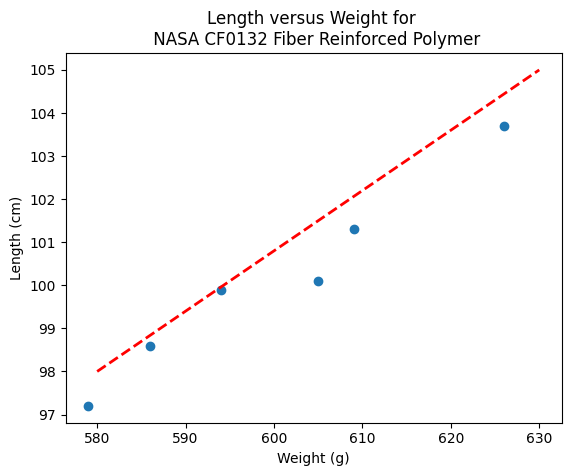

In [137]:
# Make two lists
sample_length = [101.3,103.7,98.6,99.9,97.2,100.1]
sample_weight = [609,626,586,594,579,605]
# We will assume weight is the explainatory variable, and it is to be used to predict length.
makeAbear(sample_weight, sample_length,580,98,630,105,'Weight (g)','Length (cm)','Length versus Weight for \n NASA CF0132 Fiber Reinforced Polymer')

Notice the dashed line, we supplied only two (x,y) pairs to plot the line, so lets get a colonoscope and find where it came from.

In [138]:
def myline(slope,intercept,value1,value2):
    '''Returns a tuple ([x1,x2],[y1,y2]) from y=slope*value+intercept'''
    listy = [] 
    listx = []
    listx.append(value1)
    listx.append(value2)
    listy.append(slope*listx[0]+intercept)
    listy.append(slope*listx[1]+intercept)
    return(listx,listy)

The myline function returns a tuple, that we parse below to make the plot of the data model.  This is useful if we wish to plot beyond the range of the observations data.

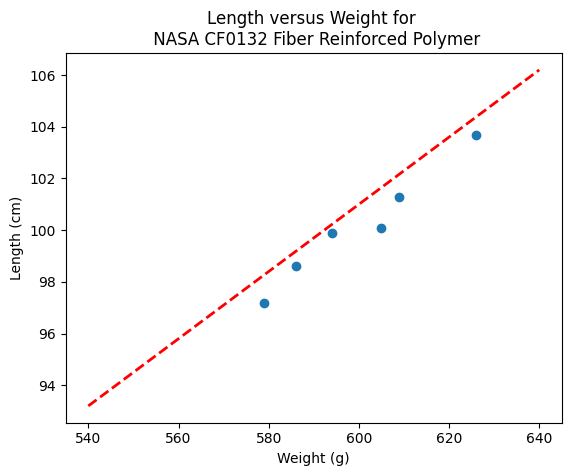

In [139]:
slope = 0.13  #0.13
intercept = 23 # 23
xlow = 540 # here we define the lower bound of the model plot
xhigh = 640 # upper bound
object = myline(slope,intercept,xlow,xhigh)
xone = object[0][0]; xtwo = object[0][1]; yone = object[1][0]; ytwo = object[1][1]
makeAbear(sample_weight, sample_length,xone,yone,xtwo,ytwo,'Weight (g)','Length (cm)','Length versus Weight for \n NASA CF0132 Fiber Reinforced Polymer')

In [140]:
print(xone,yone)
print(xtwo,ytwo)

540 93.2
640 106.2


Now lets get "optimal" values of slope and intercept from the Normal equations

In [141]:
# Evaluate the normal equations
sumx = 0.0
sumy = 0.0
sumxy = 0.0
sumx2 = 0.0
sumy2 = 0.0
for i in range(len(sample_weight)):
    sumx = sumx + sample_weight[i]
    sumx2 = sumx2 + sample_weight[i]**2
    sumy = sumy + sample_length[i]
    sumy2 = sumy2 + sample_length[i]**2
    sumxy = sumxy + sample_weight[i]*sample_length[i]
b1 = (sumx*sumy - len(sample_weight)*sumxy)/(sumx**2-len(sample_weight)*sumx2)
b0 = sumy/len(sample_length) - b1* (sumx/len(sample_weight))
lineout = ("Linear Model is y=%.3f" % b1) + ("x + %.3f" % b0)
print("Linear Model is y=%.3f" % b1 ,"x + %.3f" % b0)

Linear Model is y=0.129 x + 22.813


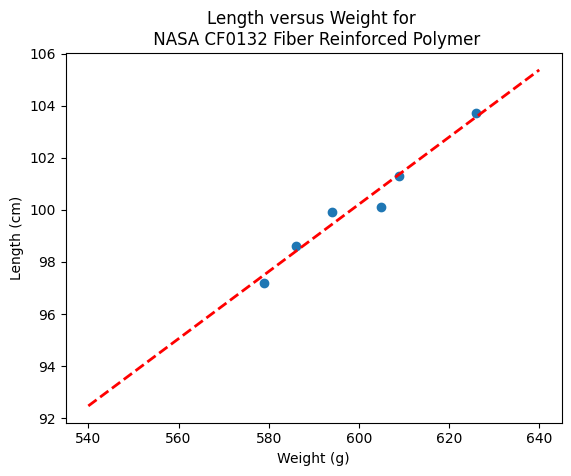

In [142]:
slope = 0.129  #0.129
intercept = 22.813  # 22.813
xlow = 540
xhigh = 640
object = myline(slope,intercept,xlow,xhigh)
xone = object[0][0]; xtwo = object[0][1]; yone = object[1][0]; ytwo = object[1][1]
makeAbear(sample_weight, sample_length,xone,yone,xtwo,ytwo,'Weight (g)','Length (cm)','Length versus Weight for \n NASA CF0132 Fiber Reinforced Polymer')

<hr>

### Where do these normal equations come from?
Consider our linear model $y = \beta_0 + \beta_1 \cdot x + \epsilon$. Where $\epsilon$ is the error in the estimate. If we square each error and add them up (for our training set) we will have $\sum \epsilon^2 = \sum (y_i - \beta_0 - \beta_1 \cdot x_i)^2 $.  Our goal is to minimize this error by our choice of $\beta_0 $ and $ \beta_1 $

The necessary and sufficient conditions for a minimum is that the first partial derivatives of the `error` as a function must vanish (be equal to zero).  We can leverage that requirement as

$\frac{\partial(\sum \epsilon^2)}{\partial \beta_0} = \frac{\partial{\sum (y_i - \beta_0 - \beta_1 \cdot x_i)^2}}{\partial \beta_0} = - \sum 2[y_i - \beta_0 + \beta_1 \cdot x_i] = -2(\sum_{i=1}^n y_i - n \beta_0 - \beta_1 \sum_{i=1}^n x_i) = 0 $

and

$\frac{\partial(\sum \epsilon^2)}{\partial \beta_1} = \frac{\partial{\sum (y_i - \beta_0 - \beta_1 \cdot x_i)^2}}{\partial \beta_1} = - \sum 2[y_i - \beta_0 + \beta_1 \cdot x_i]x_i = -2(\sum_{i=1}^n x_i y_i - n \beta_0 \sum_{i=1}^n x_i - \beta_1 \sum_{i=1}^n x_i^2) = 0 $

Solving the two equations for $\beta_0$ and $\beta_1$ produces the normal equations (for linear least squares), which leads to

$\beta_1 = \frac{\sum x\sum y~-~n\sum xy}{(\sum x)^2~-~n\sum x^2}$
$\beta_0 = \bar y - \beta_1 \bar x$



Lets consider a more flexible way by fitting the data model using linear algebra instead of the summation notation.

<hr><hr>

### Computational Linear Algebra 
We will start again with our linear data model'

:::{note}
The linear system below should be familiar, we used it in the Predictor-Response Data Model (without much background).  Here we learn it is simply the matrix equivalent of minimizing the sumn of squares error for each equation
:::

$y_i = \beta_0 + \beta_1 \cdot x_i + \epsilon_i$  then replace with vectors as

$$
\begin{gather}
\mathbf{Y}=
\begin{pmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n \\
\end{pmatrix}
\end{gather}
$$

$$\begin{gather}
\mathbf{\beta}=
\begin{pmatrix}
\beta_0 \\
\beta_1 \\
\end{pmatrix}
\end{gather}$$

$$\begin{gather}
\mathbf{X}=
\begin{pmatrix}
1 & x_1 & x_1^2\\
1 & x_2 & x_2^2\\
\vdots \\
1 & x_n & x_n^2\\
\end{pmatrix}
\end{gather}$$

$$\begin{gather}
\mathbf{\epsilon}=
\begin{pmatrix}
\epsilon_1 \\
\epsilon_2 \\
\vdots \\
\epsilon_n \\
\end{pmatrix}
\end{gather}$$

So our system can now be expressed in matrix-vector form as

$\mathbf{Y}=\mathbf{X}\mathbf{\beta}+\mathbf{\epsilon}$ if we perfrom the same vector calculus as before we will end up with a result where pre-multiply by the transpose of $\mathbf{X}$ we will have a linear system in $\mathbf{\beta}$ which we can solve using Gaussian reduction, or LU decomposition or some other similar method.

The resulting system (that minimizes $\mathbf{\epsilon^T}\mathbf{\epsilon}$) is

$\mathbf{X^T}\mathbf{Y}=\mathbf{X^T}\mathbf{X}\mathbf{\beta}$ and solving for the parameters gives
$\mathbf{\beta}=(\mathbf{X^T}\mathbf{X})^{-1}\mathbf{X^T}\mathbf{Y}$

So lets apply it to our example - what follows is mostly in python primative

In [143]:
# linearsolver with pivoting adapted from 
# https://stackoverflow.com/questions/31957096/gaussian-elimination-with-pivoting-in-python/31959226
def linearsolver(A,b):
    n = len(A)
    M = A

    i = 0
    for x in M:
     x.append(b[i])
     i += 1
# row reduction with pivots
    for k in range(n):
     for i in range(k,n):
       if abs(M[i][k]) > abs(M[k][k]):
          M[k], M[i] = M[i],M[k]
       else:
          pass

     for j in range(k+1,n):
         q = float(M[j][k]) / M[k][k]
         for m in range(k, n+1):
            M[j][m] -=  q * M[k][m]
# allocate space for result
    x = [0 for i in range(n)]
# back-substitution
    x[n-1] =float(M[n-1][n])/M[n-1][n-1]
    for i in range (n-1,-1,-1):
      z = 0
      for j in range(i+1,n):
          z = z  + float(M[i][j])*x[j]
      x[i] = float(M[i][n] - z)/M[i][i]
# return result
    return(x)
#######

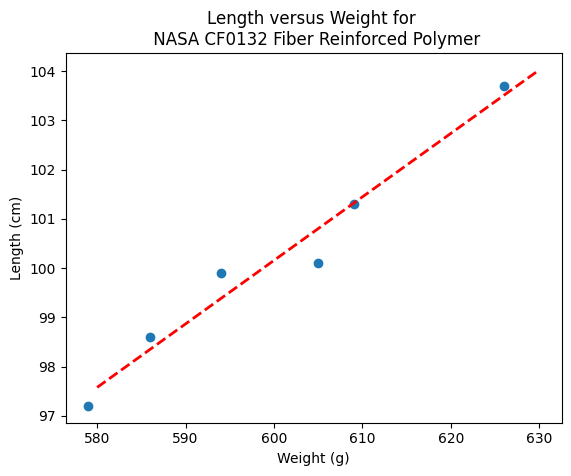

In [144]:
# matrix multiply script
def mmult(amatrix,bmatrix,rowNumA,colNumA,rowNumB,colNumB):
    result_matrix = [[0 for j in range(colNumB)] for i in range(rowNumA)]
    for i in range(0,rowNumA):
        for j in range(0,colNumB):
            for k in range(0,colNumA):
                result_matrix[i][j]=result_matrix[i][j]+amatrix[i][k]*bmatrix[k][j]
    return(result_matrix)
# matrix vector multiply script
def mvmult(amatrix,bvector,rowNumA,colNumA):
    result_v = [0 for i in range(rowNumA)]
    for i in range(0,rowNumA):
        for j in range(0,colNumA):
                result_v[i]=result_v[i]+amatrix[i][j]*bvector[j]
    return(result_v)

colNumX=2 #
rowNumX=len(sample_weight)
xmatrix = [[1 for j in range(colNumX)]for i in range(rowNumX)]
xtransp = [[1 for j in range(rowNumX)]for i in range(colNumX)]
yvector = [0 for i in range(rowNumX)]
for irow in range(rowNumX):
    xmatrix[irow][1]=sample_weight[irow]
    xtransp[1][irow]=sample_weight[irow]
    yvector[irow]   =sample_length[irow]
xtx = [[0 for j in range(colNumX)]for i in range(colNumX)]
xty = []

xtx = mmult(xtransp,xmatrix,colNumX,rowNumX,rowNumX,colNumX)
xty = mvmult(xtransp,yvector,colNumX,rowNumX)

beta = []
#solve XtXB = XtY for B
beta = linearsolver(xtx,xty) #Solve the linear system  What would the numpy equivalent be?

slope = beta[1] #0.129
intercept = beta[0]  # 22.813
xlow = 580
xhigh = 630
object = myline(slope,intercept,xlow,xhigh)
xone = object[0][0]; xtwo = object[0][1]; yone = object[1][0]; ytwo = object[1][1]
makeAbear(sample_weight, sample_length,xone,yone,xtwo,ytwo,'Weight (g)','Length (cm)','Length versus Weight for \n NASA CF0132 Fiber Reinforced Polymer')

In [145]:
beta

[22.812624584693076, 0.12890365448509072]

---

#### What's the Value of the Computational Linear Algebra ?

The value comes when we have more explainatory variables, and we may want to deal with curvature.

:::{note}
The lists below are different that the example above!
:::

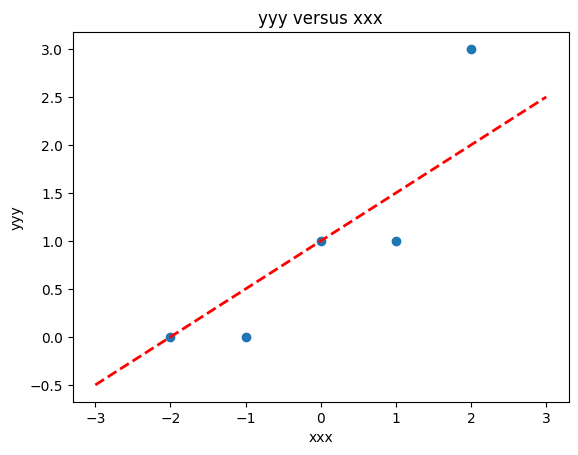

In [146]:
# Make two lists
yyy = [0,0,1,1,3]
xxx = [-2,-1,0,1,2]
slope = 0.5  #0.129
intercept = 1  # 22.813
xlow = -3
xhigh = 3
object = myline(slope,intercept,xlow,xhigh)
xone = object[0][0]; xtwo = object[0][1]; yone = object[1][0]; ytwo = object[1][1]
makeAbear(xxx, yyy,xone,yone,xtwo,ytwo,'xxx','yyy','yyy versus xxx')

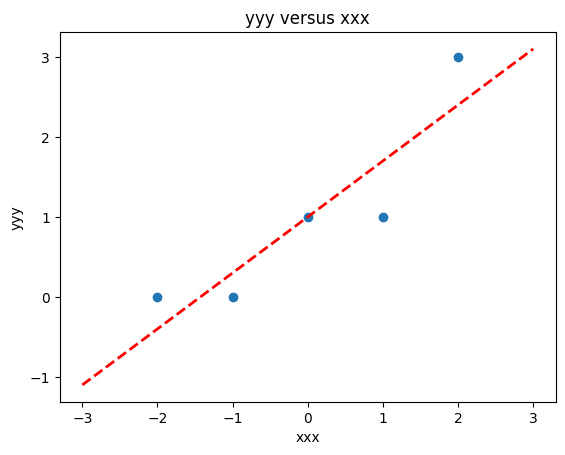

In [147]:
colNumX=2 #
rowNumX=len(xxx)
xmatrix = [[1 for j in range(colNumX)]for i in range(rowNumX)]
xtransp = [[1 for j in range(rowNumX)]for i in range(colNumX)]
yvector = [0 for i in range(rowNumX)]
for irow in range(rowNumX):
    xmatrix[irow][1]=xxx[irow]
    xtransp[1][irow]=xxx[irow]
    yvector[irow]   =yyy[irow]
xtx = [[0 for j in range(colNumX)]for i in range(colNumX)]
xty = []

xtx = mmult(xtransp,xmatrix,colNumX,rowNumX,rowNumX,colNumX)
xty = mvmult(xtransp,yvector,colNumX,rowNumX)

beta = []
#solve XtXB = XtY for B
beta = linearsolver(xtx,xty) #Solve the linear system

slope = beta[1] #0.129
intercept = beta[0]  # 22.813
xlow = -3
xhigh = 3
object = myline(slope,intercept,xlow,xhigh)
xone = object[0][0]; xtwo = object[0][1]; yone = object[1][0]; ytwo = object[1][1]
makeAbear(xxx, yyy,xone,yone,xtwo,ytwo,'xxx','yyy','yyy versus xxx')

In [148]:
colNumX=4 #
rowNumX=len(xxx)
xmatrix = [[1 for j in range(colNumX)]for i in range(rowNumX)]
xtransp = [[1 for j in range(rowNumX)]for i in range(colNumX)]
yvector = [0 for i in range(rowNumX)]
for irow in range(rowNumX):
    xmatrix[irow][1]=xxx[irow]
    xmatrix[irow][2]=xxx[irow]**2
    xmatrix[irow][3]=xxx[irow]**3
    xtransp[1][irow]=xxx[irow]
    xtransp[2][irow]=xxx[irow]**2
    xtransp[3][irow]=xxx[irow]**3
    yvector[irow]   =yyy[irow]
xtx = [[0 for j in range(colNumX)]for i in range(colNumX)]
xty = []

xtx = mmult(xtransp,xmatrix,colNumX,rowNumX,rowNumX,colNumX)
xty = mvmult(xtransp,yvector,colNumX,rowNumX)

beta = []
#solve XtXB = XtY for B
beta = linearsolver(xtx,xty) #Solve the linear system



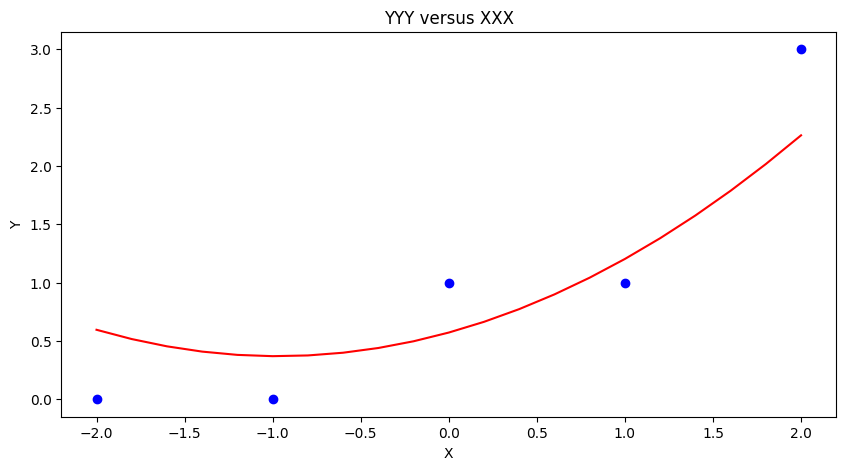

In [149]:
howMany = 20
xlow = -2
xhigh = 2
deltax = (xhigh - xlow)/howMany
xmodel = []
ymodel = []
for i in range(howMany+1):
    xnow = xlow + deltax*float(i)
    xmodel.append(xnow)
    ymodel.append(beta[0]+beta[1]*xnow+beta[2]*xnow**2)

# Now plot the sample values and plotting position
import matplotlib.pyplot 
myfigure = matplotlib.pyplot.figure(figsize = (10,5)) # generate a object from the figure class, set aspect ratio

# Built the plot
matplotlib.pyplot.scatter(xxx, yyy,  color ='blue') 
matplotlib.pyplot.plot(xmodel, ymodel,  color ='red') 
matplotlib.pyplot.ylabel("Y") 
matplotlib.pyplot.xlabel("X") 
mytitle = "YYY versus XXX"
matplotlib.pyplot.title(mytitle) 
matplotlib.pyplot.show()

### Using packages

So in core python, there is a fair amount of work involved to write script - how about an easier way? First lets get things into a dataframe. Using the lists from the example above we can build a dataframe using pandas.

In [150]:
# Load the necessary packages
import numpy as np
import pandas as pd
import statistics 
from matplotlib import pyplot as plt

# Create a dataframe:
data = pd.DataFrame({'X':xxx, 'Y':yyy})
data

,X,Y
0,-2,0
1,-1,0
2,0,1
3,1,1
4,2,3


#### `statsmodel` package

Now load in one of many modeling packages that have regression tools.  Here we use **statsmodel** which is an API (applications programming interface) with a nice formula syntax.  In the package call we use `Y~X` which is interpreted by the API as fit `Y` as a linear function of `X`, which interestingly is our design matrix from a few lessons ago.

In [151]:
# repeat using statsmodel
import statsmodels.formula.api as smf

# Initialise and fit linear regression model using `statsmodels`
model = smf.ols('Y ~ X', data=data) # model object constructor syntax
model = model.fit()

Now recover the parameters of the model

In [152]:
model.params

Intercept    1.0
X            0.7
dtype: float64

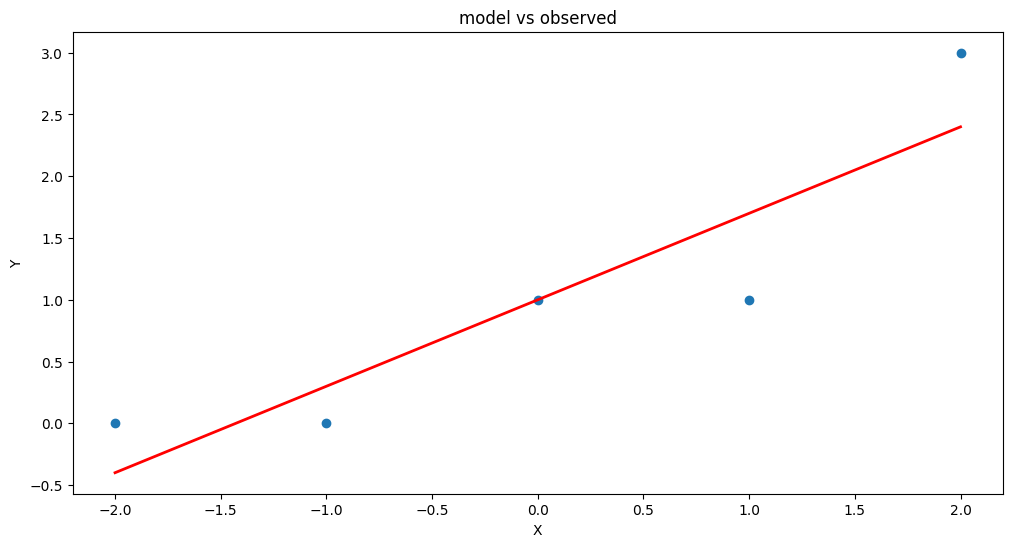

In [153]:
# Predict values
y_pred = model.predict()

# Plot regression against actual data
plt.figure(figsize=(12, 6))
plt.plot(data['X'], data['Y'], 'o')           # scatter plot showing actual data
plt.plot(data['X'], y_pred, 'r', linewidth=2)   # regression line
plt.xlabel('X')
plt.ylabel('Y')
plt.title('model vs observed')

plt.show();

We could use our own plotting functions if we wished, and would obtain an identical plot

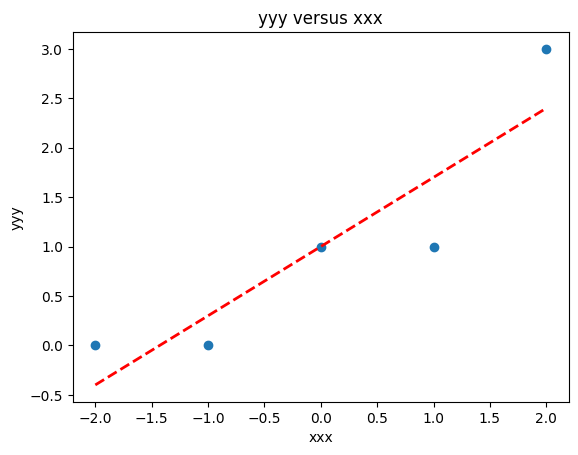

In [154]:
slope = model.params[1] #0.7
intercept = model.params[0]  # 1.0
xlow = -2
xhigh = 2
object = myline(slope,intercept,xlow,xhigh)
xone = object[0][0]; xtwo = object[0][1]; yone = object[1][0]; ytwo = object[1][1]
makeAbear(data['X'], data['Y'],xone,yone,xtwo,ytwo,'xxx','yyy','yyy versus xxx')

Now lets add another column $x^2$ to introduce the ability to fit some curvature

In [155]:
data['XX']=data['X']**2  # add a column of X^2
model = smf.ols('Y ~ X + XX', data=data) # model object constructor syntax
model = model.fit()
model.params

Intercept    0.571429
X            0.700000
XX           0.214286
dtype: float64

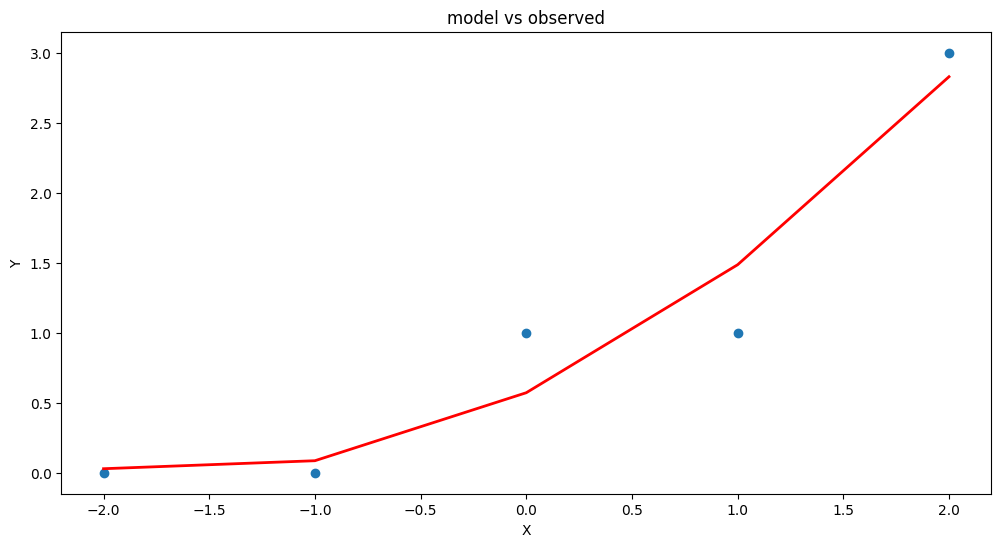

In [156]:
# Predict values
y_pred = model.predict()

# Plot regression against actual data
plt.figure(figsize=(12, 6))
plt.plot(data['X'], data['Y'], 'o')           # scatter plot showing actual data
plt.plot(data['X'], y_pred, 'r', linewidth=2)   # regression line
plt.xlabel('X')
plt.ylabel('Y')
plt.title('model vs observed')

plt.show();

Our homebrew plotting tool could be modified a bit (shown below just cause ...)

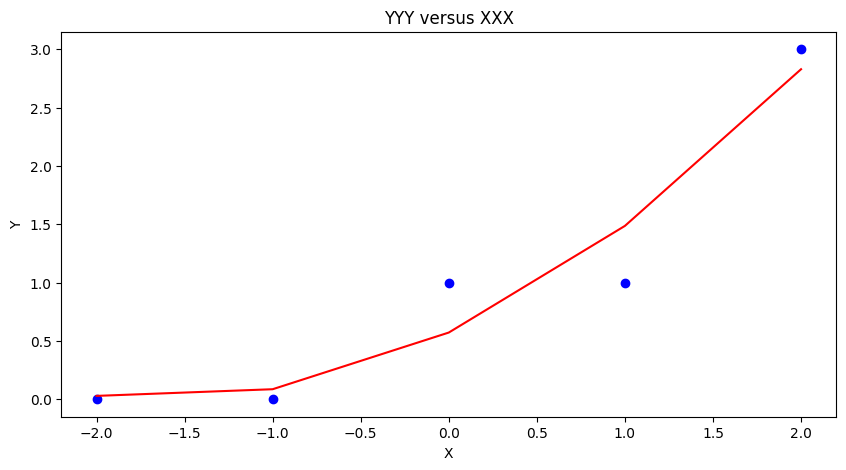

In [157]:
myfigure = matplotlib.pyplot.figure(figsize = (10,5)) # generate a object from the figure class, set aspect ratio

# Built the plot
matplotlib.pyplot.scatter(data['X'], data['Y'],  color ='blue') 
matplotlib.pyplot.plot(data['X'], y_pred,  color ='red') 
matplotlib.pyplot.ylabel("Y") 
matplotlib.pyplot.xlabel("X") 
mytitle = "YYY versus XXX"
matplotlib.pyplot.title(mytitle) 
matplotlib.pyplot.show()

Another useful package is **sklearn** so repeat using that tool (same example)

#### `sklearn` package

In [158]:
# repeat using sklearn
# Multiple Linear Regression with scikit-learn:
from sklearn.linear_model import LinearRegression

# Build linear regression model using X,XX as predictors
# Split data into predictors X and output Y
predictors = ['X', 'XX']
X = data[predictors]
y = data['Y']

# Initialise and fit model
lm = LinearRegression()  # This is the sklearn model tool here
model = lm.fit(X, y)

In [159]:
print(f'alpha = {model.intercept_}')
print(f'betas = {model.coef_}')

alpha = 0.5714285714285714
betas = [0.7        0.21428571]


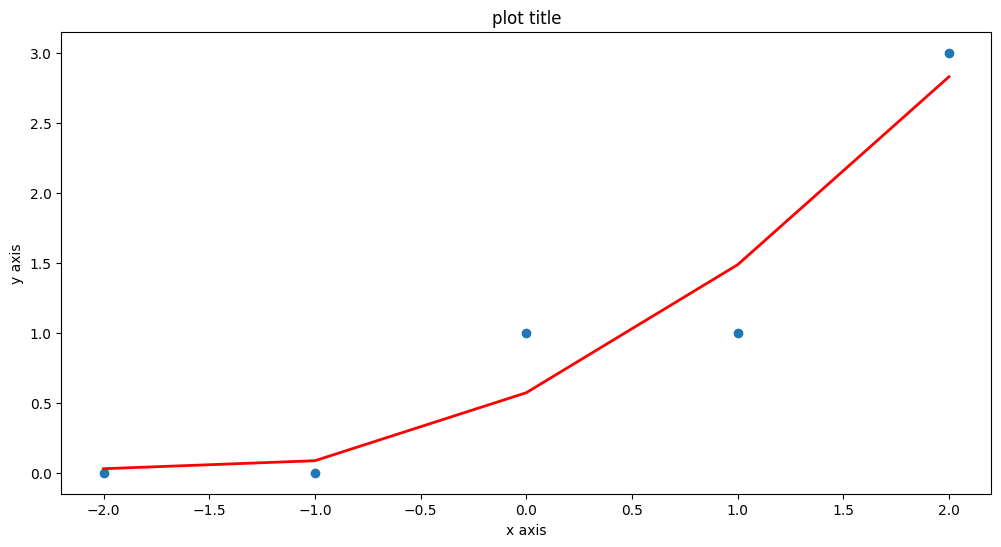

In [160]:
fitted = model.predict(X)

# Plot regression against actual data - What do we see?
plt.figure(figsize=(12, 6))
plt.plot(data['X'], data['Y'], 'o')           # scatter plot showing actual data
plt.plot(data['X'], fitted,'r', linewidth=2)   # regression line
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.title('plot title')

plt.show();

#### Now repeat using the original Texas Instruments example


In [161]:
sample_length = [101.3,103.7,98.6,99.9,97.2,100.1]
sample_weight = [609,626,586,594,579,605]
data = pd.DataFrame({'X':sample_weight, 'Y':sample_length})
data

,X,Y
0,609,101.3
1,626,103.7
2,586,98.6
3,594,99.9
4,579,97.2
5,605,100.1


In [162]:

# Build linear regression model using X,XX as predictors
# Split data into predictors X and output Y
predictors = ['X']
X = data[predictors]
y = data['Y']

# Initialise and fit model
lm = LinearRegression()
model = lm.fit(X, y)
print(f'alpha = {model.intercept_}')
print(f'betas = {model.coef_}')

alpha = 22.812624584717597
betas = [0.12890365]


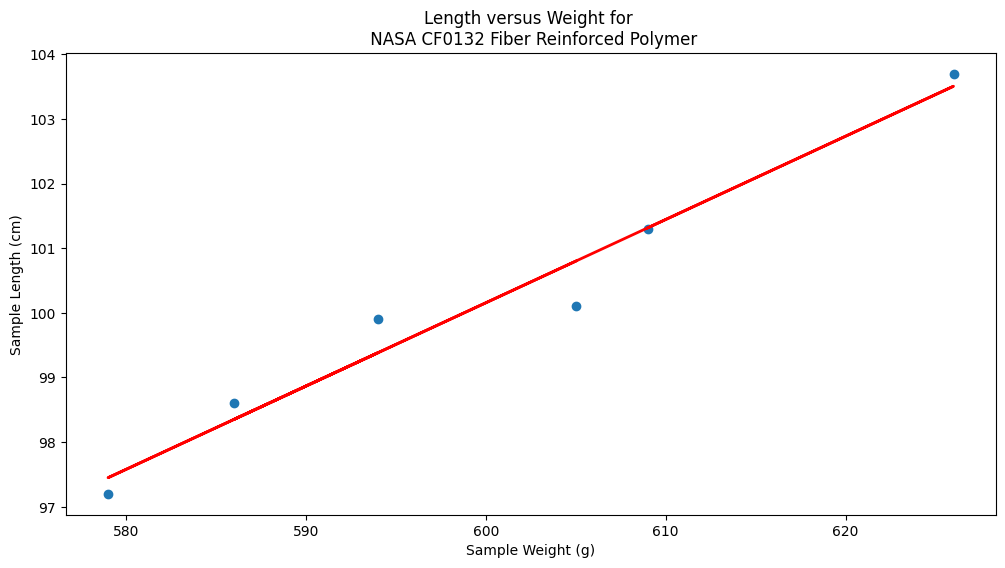

In [163]:
fitted = model.predict(X)
xvalue=data['X'].to_numpy()

# Plot regression against actual data - What do we see?
plt.figure(figsize=(12, 6))
plt.plot(data['X'], data['Y'], 'o')           # scatter plot showing actual data
plt.plot(xvalue, fitted, 'r', linewidth=2)   # regression line
plt.xlabel('Sample Weight (g)')
plt.ylabel('Sample Length (cm)')
plt.title('Length versus Weight for \n NASA CF0132 Fiber Reinforced Polymer')

plt.show();

### Summary

We examined regression as a way to fit lines to data (and make predictions from those lines).  The methods presented are

1. Using the normal equations (pretty much restricted to a linear model)
2. Constructed as a linear system of equations using $Y=X \cdot \beta$ where $X$ is the design matrix.  We used homebrew solver, but `numpy.linalg` would be a better bet for practice.
3. Using `statsmodel` package
4. Using `sklearn` package

```{note}
There are probably dozens of other ways to perform linear regression - different packages and such.  Just read the package documentation, construct a simple example so you understand the function call(s) and you can regress to your heart's content.
```

# 4.1 Application Example(s)

## Dose–Response Prediction(s)
Most therapeutic drugs provide medical benefit only when delivered within a specific dosage range. If the dose is too low, it may fall below the therapeutic threshold and fail to achieve the desired clinical effect. Conversely, if the dose is too high, it may exceed the toxic threshold, leading to harmful side effects or systemic toxicity. The range between these two limits is called the therapeutic window, and maintaining drug concentrations within this window is a central objective in pharmaceutical development and clinical dosing protocols.

To achieve this, engineers and pharmacologists often use mathematical models to design and optimize drug delivery systems. These models help ensure that drug levels in the body stay within the therapeutic window, taking into account factors such as absorption, distribution, metabolism, and excretion. In particular, drug delivery systems based on nanoparticles offer unique opportunities to target specific cells or tissues and to control the timing and location of drug release.

In this problem set, we focus on one component of the broader drug delivery process: the prediction of drug concentration over time from a controlled-release nanoparticle system. This type of experiment is typically conducted in vitro (outside the body) as a preliminary step before in vivo trials. The goal is to model the dose–response curve — specifically, how much drug is released over time under controlled conditions.

We will explore this using regression techniques — a foundational method in machine learning — to build predictive models that approximate the drug release behavior observed in experiments. The data used in this exercise is based on a study titled “Nanosystems for Simultaneous Imaging and Drug Delivery to T Cells” by Fahmy et al. (AAPS Journal, 2007, Vol. 9), which presents experimental results of drug release from biodegradable nanoparticles designed for targeted immunotherapy.

|Time(Days) | $\mu$-grams released|
|---|---|
|0 |2.5|
|0.25|3.6|
|0.5|5.3|
|1|9.5|
|2|14.0|
|3|16.5|
|4|18.8|
|5|21.5|
|6|23.2|
|8|26.8|
|10|28.4|

By applying regression analysis to this experimental data, we can begin to answer important engineering questions:

- How quickly is the drug released?

- What type of mathematical function (this is the "Machine Learning" component best captures the release behavior (e.g., linear, exponential, or logistic)?

- How might such models inform nanoparticle design decisions or therapeutic scheduling?

The datasets and modeling exercises that follow will help build intuition for how simple mathematical tools can be used to simulate, fit, and eventually optimize real-world engineered systems — bridging biology, chemistry, and computation in the process.

### Exploratory Data Analysis (Linear Model)

Using the drug release data first we will examine a linear model

$\mu g_{release} = \beta_0 + \beta_1 \cdot t_{days} $ 

1. Plot the drug release data with time on the horizontal axis, and mass released on the vertical axis. Use red circles as the marker. 

2. Create and plot a linear data model using a blue curve for the model. $\mu g_{release} = \beta_0 + \beta_1 \cdot t_{days}$ 

3. Create a list of prediction error; produce a histogram of these errors (called residuals).

4. Compute the sum of the squares of all of the residuals.

In the scripts below, I intentionally purge memory each run - its not a usual procedure, but the last two "models" are tempermental.

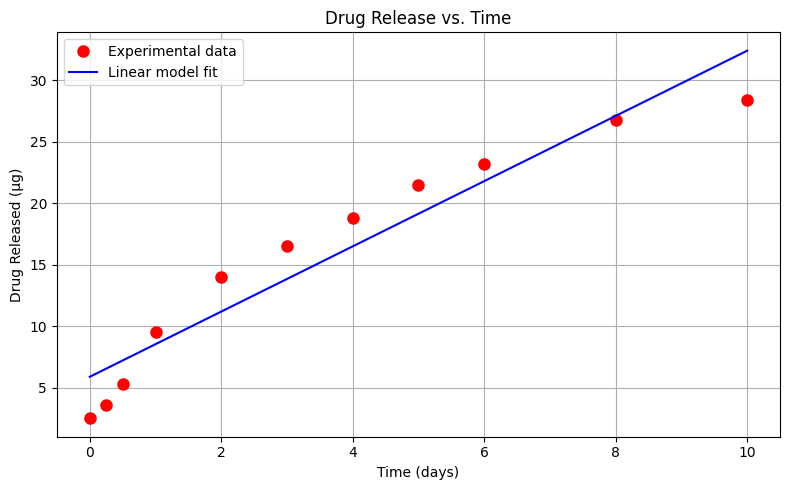

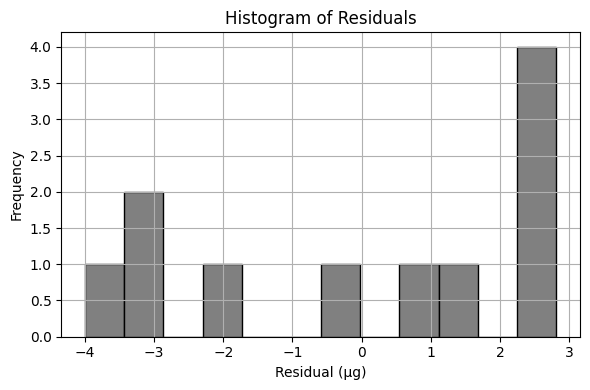

Sum of Squared Residuals: 68.667 µg²


In [164]:
%reset -f
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")  # Optional: suppress warnings for cleaner output

# --- Linear Model Function ---
def drug_response(a, b, t):
    """Linear drug release response model."""
    return a + b * t

# --- Experimental Data ---
bac = [2.5, 3.6, 5.3, 9.5, 14, 16.5, 18.8, 21.5, 23.2, 26.8, 28.4]  # micrograms released
time = [0, 0.25, 0.5, 1, 2, 3, 4, 5, 6, 8, 10]  # days

# --- Least Squares Fit to Estimate a and b ---
x = np.array(time)
y = np.array(bac)
A = np.vstack([x, np.ones(len(x))]).T
b_est, a_est = np.linalg.lstsq(A, y, rcond=None)[0]

# --- Model Predictions ---
bac_model = drug_response(a_est, b_est, x)

# --- Plot Data and Model ---
plt.figure(figsize=(8, 5))
plt.plot(x, y, 'o', label='Experimental data', color='red', markersize=8)
plt.plot(x, bac_model, '-', label='Linear model fit', color='blue')
plt.xlabel('Time (days)')
plt.ylabel('Drug Released (µg)')
plt.title('Drug Release vs. Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Residuals and Their Histogram ---
residuals = y - bac_model

plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=12, color='gray', edgecolor='black')
plt.title('Histogram of Residuals')
plt.xlabel('Residual (µg)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Sum of Squares of Residuals ---
sum_squared_residuals = np.sum(residuals**2)
print(f"Sum of Squared Residuals: {sum_squared_residuals:.3f} µg²")

### Exploratory Data Analysis (Quadratic Model)

Using the same drug release data, lets repeat the analysis using a quadratic data model 

$\mu g_{release} = \beta_0 + \beta_1 \cdot t_{days} + \beta_2 \cdot t_{days}^2 $ 

1. Perform your trial-and-error fit for this model. Report the sum of square of residuals of your fitted data model.


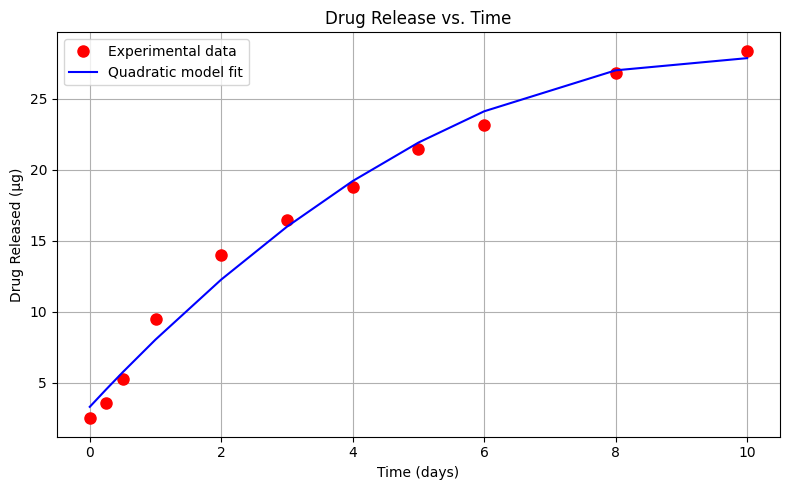

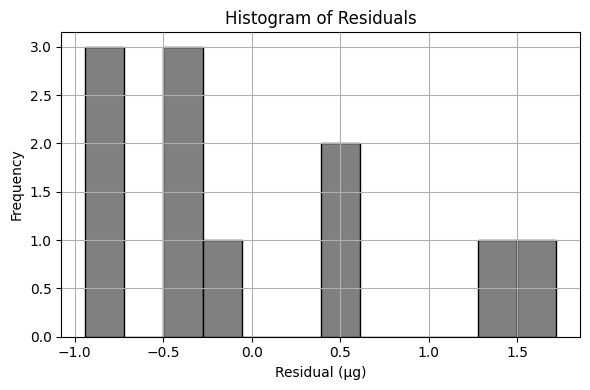

Sum of Squared Residuals: 8.611 µg²


In [165]:
%reset -f
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")  # Optional: suppress warnings for cleaner output

# --- Linear Model Function ---
def drug_response(a, b, t):
    """Linear drug release response model."""
    return a + b * t

def drug_responsePoly(a, b, c, t):
    """Quadratic (in t) drug release response model."""
    return a + b * t + c * t**2

# --- Experimental Data ---
bac = [2.5, 3.6, 5.3, 9.5, 14, 16.5, 18.8, 21.5, 23.2, 26.8, 28.4]  # micrograms released
time = [0, 0.25, 0.5, 1, 2, 3, 4, 5, 6, 8, 10]  # days

# --- Least Squares Fit to Estimate a and b ---
x = np.array(time)
xx = x*x 
y = np.array(bac)
A = np.vstack([xx, x, np.ones(len(x))]).T
c_est, b_est, a_est = np.linalg.lstsq(A, y, rcond=None)[0]

# --- Model Predictions ---
bac_model = drug_responsePoly(a_est, b_est, c_est, x)

# --- Plot Data and Model ---
plt.figure(figsize=(8, 5))
plt.plot(x, y, 'o', label='Experimental data', color='red', markersize=8)
plt.plot(x, bac_model, '-', label='Quadratic model fit', color='blue')
plt.xlabel('Time (days)')
plt.ylabel('Drug Released (µg)')
plt.title('Drug Release vs. Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Residuals and Their Histogram ---
residuals = y - bac_model

plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=12, color='gray', edgecolor='black')
plt.title('Histogram of Residuals')
plt.xlabel('Residual (µg)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Sum of Squares of Residuals ---
sum_squared_residuals = np.sum(residuals**2)
print(f"Sum of Squared Residuals: {sum_squared_residuals:.3f} µg²")

### Exploratory Data Analysis (Cubic Model)

Using the same drug release data, let's repeat the analysis using a cubic (in time) data model 

$\mu g_{release} = \beta_0 + \beta_1 \cdot t_{days} + \beta_2 \cdot t_{days}^2 + \beta_3 \cdot t_{days}^3$ 

1. Perform your trial-and-error fit. Report the sum of square of residuals of your fitted data model.

2. What is the order of the polynomial that gives the best fit in terms of the lowest sum of square of residuals? 

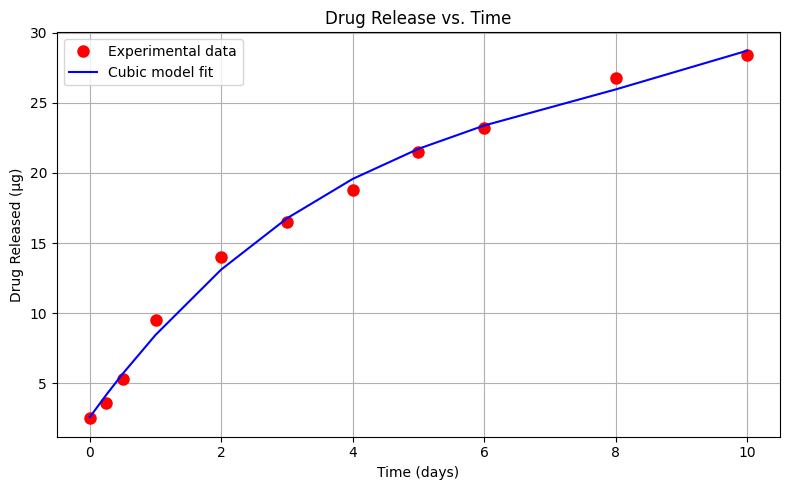

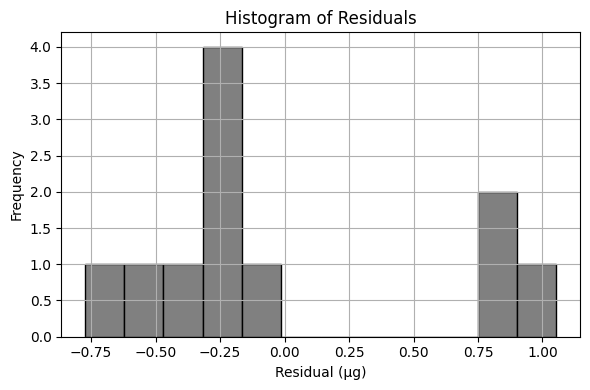

Sum of Squared Residuals: 3.931 µg²
Estimated Parameters: β₀ = 2.582, β₁ = 6.521, β₃ = -0.686, β₄ = 0.030


In [166]:
%reset -f
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")  # Optional: suppress warnings for cleaner output

# --- Linear Model Function ---
def drug_response(a, b, t):
    """Linear drug release response model."""
    return a + b * t

def drug_responseQuad(a, b, c, t):
    """Quadratic (in t) drug release response model."""
    return a + b * t + c * t**2

def drug_responseCubic(a, b, c, d, t):
    """Cubic (in t) drug release response model."""
    return a + b * t + c * t**2 + d * t**3

# --- Experimental Data ---
bac = [2.5, 3.6, 5.3, 9.5, 14, 16.5, 18.8, 21.5, 23.2, 26.8, 28.4]  # micrograms released
time = [0, 0.25, 0.5, 1, 2, 3, 4, 5, 6, 8, 10]  # days

# --- Least Squares Fit to Estimate a and b ---
x = np.array(time)
xx = x*x 
xxx = xx*x
y = np.array(bac)
A = np.vstack([xxx,xx, x, np.ones(len(x))]).T
d_est, c_est, b_est, a_est = np.linalg.lstsq(A, y, rcond=None)[0]

# --- Model Predictions ---
bac_model = drug_responseCubic(a_est, b_est, c_est, d_est, x)

# --- Plot Data and Model ---
plt.figure(figsize=(8, 5))
plt.plot(x, y, 'o', label='Experimental data', color='red', markersize=8)
plt.plot(x, bac_model, '-', label='Cubic model fit', color='blue')
plt.xlabel('Time (days)')
plt.ylabel('Drug Released (µg)')
plt.title('Drug Release vs. Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Residuals and Their Histogram ---
residuals = y - bac_model

plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=12, color='gray', edgecolor='black')
plt.title('Histogram of Residuals')
plt.xlabel('Residual (µg)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Sum of Squares of Residuals ---
sum_squared_residuals = np.sum(residuals**2)
print(f"Sum of Squared Residuals: {sum_squared_residuals:.3f} µg²")
#print(f"Estimated Parameters: β₀ = {a_est:.3f}, β₁ = {b_est:.3f}, β3 = {c_est:.3f}, β4 = {d_est:.3f}")
print(f"Estimated Parameters: β₀ = {a_est:.3f}, β₁ = {b_est:.3f}, β₃ = {c_est:.3f}, β₄ = {d_est:.3f}")

### Exploratory Data Analysis (Power-Law Model)

Using the same drug release data, let's repeat the analysis using an power-law type model 

$\mu g_{release} = \beta_0 \cdot (t_{days})^{\beta_1} $

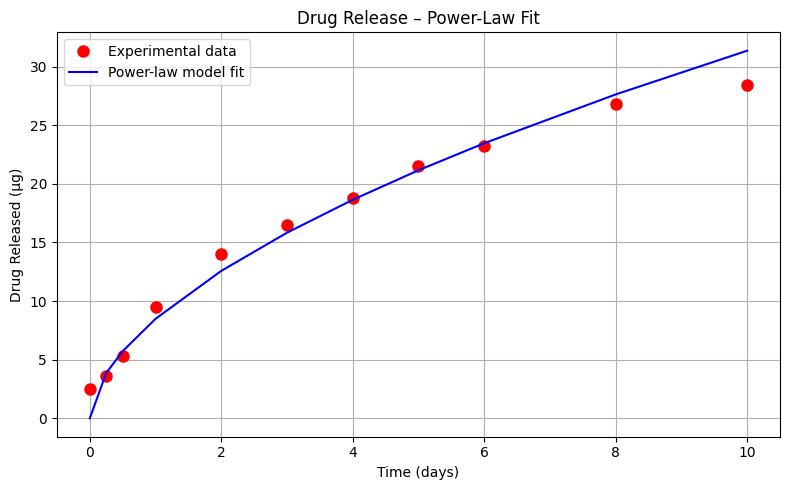

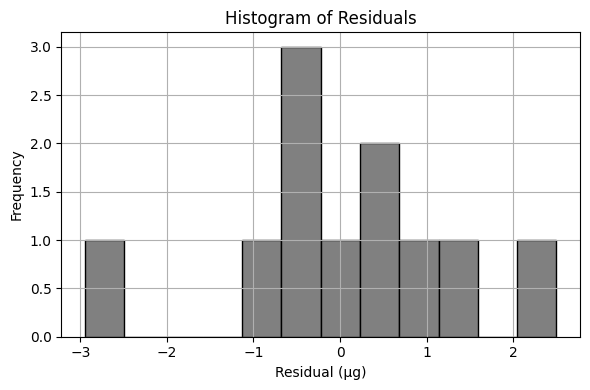

Sum of Squared Residuals (Power-Law Model): 19.590 µg²
Estimated Parameters: β₀ = 8.484, β₁ = 0.568


In [167]:
%reset -f
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")  # Optional: suppress warnings for cleaner output

# Define a power-law model 
def drug_response_powerlaw(beta0, beta1, t):
    return beta0 * t**beta1
    
# --- Experimental Data ---
bac = [2.5, 3.6, 5.3, 9.5, 14, 16.5, 18.8, 21.5, 23.2, 26.8, 28.4]  # micrograms released
time = [0.0, 0.25, 0.5, 1, 2, 3, 4, 5, 6, 8, 10]  # days

# --- Least Squares Fit to Estimate a and b ---
x = np.array(time)
y = np.array(bac)

# Remove the zero-time entry to avoid log(0)
x_pow = x[1:]
y_pow = y[1:]

log_x = np.log(x_pow)
log_y = np.log(y_pow)

# Linear regression on log-log data
A_pow = np.vstack([log_x, np.ones(len(log_x))]).T
b_pow, a_pow = np.linalg.lstsq(A_pow, log_y, rcond=None)[0]

# Recover original parameters
beta0 = np.exp(a_pow)
beta1 = b_pow

bac_model_pow = drug_response_powerlaw(beta0, beta1, x)

# Plot original data and power-law fit
plt.figure(figsize=(8, 5))
plt.plot(x, y, 'o', label='Experimental data', color='red', markersize=8)
plt.plot(x, bac_model_pow, '-', label='Power-law model fit', color='blue')
plt.xlabel('Time (days)')
plt.ylabel('Drug Released (µg)')
plt.title('Drug Release – Power-Law Fit')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Residuals and Their Histogram ---
residuals_pow = y - bac_model_pow

plt.figure(figsize=(6, 4))
plt.hist(residuals_pow, bins=12, color='gray', edgecolor='black')
plt.title('Histogram of Residuals')
plt.xlabel('Residual (µg)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

ssr_pow = np.sum(residuals_pow**2)
print(f"Sum of Squared Residuals (Power-Law Model): {ssr_pow:.3f} µg²")
print(f"Estimated Parameters: β₀ = {beta0:.3f}, β₁ = {beta1:.3f}")

Let's summarize the results so far

|Model Type|Equation|ML Technique      |$\sum{residuals^2}$|
|----------|--------|----------------------|------------------:|
|Linear    |$\mu g_{release} = \beta_0 + \beta_1 \cdot t_{days} $ |OLS|68.667 µg²|
|Quadratic |$\mu g_{release} = \beta_0 + \beta_1 \cdot t_{days} + \beta_2 \cdot t_{days}^2 $ |OLS|8.611 µg²|
|Cubic     |$\mu g_{release} = \beta_0 + \beta_1 \cdot t_{days} + \beta_2 \cdot t_{days}^2 + \beta_3 \cdot t_{days}^3$ |OLS|3.931 µg²|
|Power-Law |$\mu g_{release} = \beta_0 \cdot (t_{days})^{\beta_1} $|OLS|    19.590 µg²|

OLS == Ordinary Least Squares

These results indicate that, based on the sum of squared residuals, the cubic model provides the best fit to the experimental data. This conclusion is reinforced by visual inspection of the plotted model curves. However, it's important to consider the model’s behavior beyond the data range. Toward the later time points, the cubic model appears to curve upward, suggesting it may predict increasing drug release at longer durations—this may or may not be realistic depending on the pharmacokinetics of the system.

In contrast, the quadratic model curves downward at later times, implying a saturation effect where increasing time yields diminishing additional release. For many drugs, especially those with well-defined therapeutic windows, this behavior is desirable—it reflects the diminishing marginal effect of higher doses and helps mitigate side effects. A drug whose delivery system naturally plateaus is less likely to oversaturate and cause harm, making the quadratic model’s long-term behavior potentially more realistic despite its slightly higher residual error.

It’s worth emphasizing that this example is intended to illustrate machine learning concepts, particularly regression modeling, and not to serve as medical research. That said, the intersection of modeling and medicine is exactly where these methods find meaningful application.

### Exploratory Data Analysis (Exponential Decay Model)

Let's explore one more model; an exponential-decay type model 

$\mu g_{release} = \beta_0 (1- e^{-\beta_1 \cdot t_{days}}) $ 

1. Perform your trial-and-error fit for this model. Report the sum of square of residuals of your fitted data model.

:::{note}
This cannot be solved by linear regression - the form of the prototype is indeed non-linear, however a useful rule of thumb for this kind of structure is:
1. $\beta_0$ is roughly the horizontal asymptote, in our case around 33 (an educated guess).
2. $\beta_1$ is an exponential decay time constant, roughly 5 time constants should get us to within 10% the asymptote.  In the data herein, we get our asymptote at 10 time units. So $\beta_1$ should be around $\frac{1}{5}$

:::

Let’s explore one more model – an exponential saturation type model, which is frequently used in pharmacology and mass transfer to represent accumulation processes. The model has the form:

$$
\mu g_{\text{release}} = \beta_0 \left(1 - e^{-\beta_1 \cdot t_{\text{days}}} \right)
$$

This form captures the behavior of a system where the rate of change is initially rapid and gradually slows down as it approaches a limiting value. It is a natural fit for systems where the release of a substance (such as a drug) slows over time due to saturation effects or declining gradients.

#### Instructions
1. Perform a trial-and-error fit for this model using your knowledge of the system behavior.
2. Implement an unconstrained optimization method to minimize the sum of squared residuals between the observed data and model predictions.
3. Plot the fitted model alongside the experimental data, then report the sum of squared residuals (SSR) for your model.

:::{note}
This model cannot be solved using linear regression — the exponential term introduces non-linearity in the parameters. However, we can still approach it using general-purpose optimization techniques.

Here are two useful rules of thumb to help guide your initial parameter estimates:

1. Asymptote estimate $\beta_0$: This is the maximum expected release value. From the observed data, it appears that the cumulative release levels off near 33 µg.
2. Time constant estimate $\beta_1$: A typical rule in exponential behavior is that 5 time constants are needed to reach ~95% of the asymptotic value. The data flattens at around 10 days, a reasonable estimate is:

$$
   \beta_1 \approx \frac{1}{5}
$$

These estimates can serve as a starting point for numerical methods such as Powell’s or Nelder-Mead to find the best-fitting parameters.
:::

While the **cubic model** still provides the best fit in terms of lowest SSR, the **exponential model** is grounded in physical and biological reality. It aligns with established **pharmacokinetic principles** (e.g., drug absorption curves) and **diffusion-driven transport** behavior. This makes the exponential model not only a plausible fit, but also a **theoretically justifiable** choice in real-world applications.

In future lessons, we’ll formally introduce **non-linear optimization** methods and explore how to handle constraints, estimate confidence intervals for parameters, and incorporate more complex model forms.


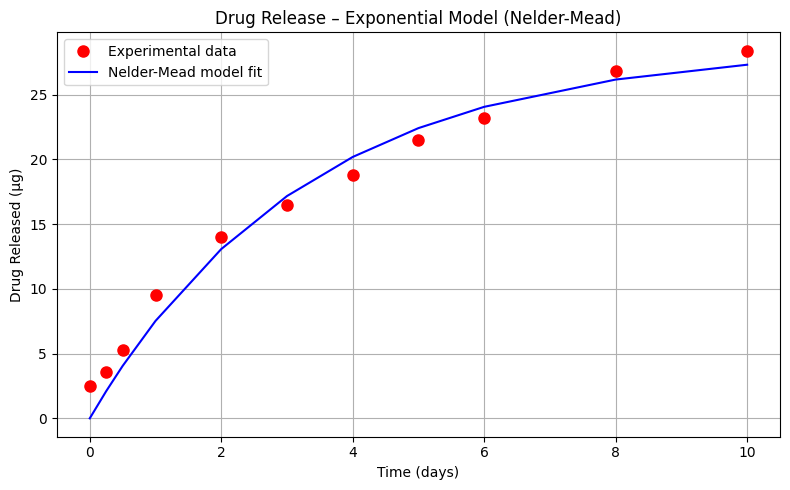

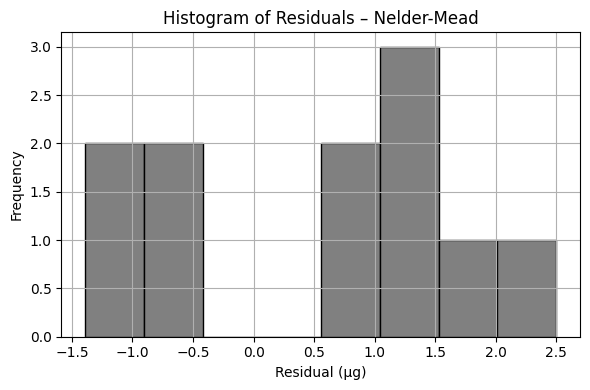

Sum of Squared Residuals (Nelder-Mead): 20.365 µg²
Estimated Parameters: β₀ = 28.686, β₁ = 0.304


In [168]:
%reset -f
import numpy as np
import matplotlib.pyplot as plt
import warnings
from scipy.optimize import minimize

warnings.filterwarnings("ignore")

# --- Exponential Saturation Model Function ---
def drug_responseExp(params, t):
    b0, b1 = params
    return b0 * (1 - np.exp(-b1 * t))

# --- Objective Function: Sum of Squared Residuals ---
def objective(params, t, y_obs):
    y_pred = drug_responseExp(params, t)
    residuals = y_obs - y_pred
    return np.sum(residuals**2)

# --- Experimental Data ---
bac = [2.5, 3.6, 5.3, 9.5, 14, 16.5, 18.8, 21.5, 23.2, 26.8, 28.4]  # micrograms released
time = [0.0, 0.25, 0.5, 1, 2, 3, 4, 5, 6, 8, 10]  # days

# --- Convert to arrays
x = np.array(time)
y = np.array(bac)

# --- Initial Guess for Parameters ---
initial_guess = [33.0, 0.2]

# --- Choose optimization method: 'Powell' or 'Nelder-Mead'
method = 'Nelder-Mead'  # or 'Nelder-Mead'

# --- Run Optimization ---
result = minimize(objective, initial_guess, args=(x, y), method=method)

# --- Extract Parameters ---
b0_est, b1_est = result.x
bac_model_exp = drug_responseExp([b0_est, b1_est], x)

# --- Plot Data and Model ---
plt.figure(figsize=(8, 5))
plt.plot(x, y, 'o', label='Experimental data', color='red', markersize=8)
plt.plot(x, bac_model_exp, '-', label=f'{method} model fit', color='blue')
plt.xlabel('Time (days)')
plt.ylabel('Drug Released (µg)')
plt.title(f'Drug Release – Exponential Model ({method})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Residuals and Histogram ---
residuals_exp = y - bac_model_exp

plt.figure(figsize=(6, 4))
plt.hist(residuals_exp, bins=8, color='gray', edgecolor='black')
plt.title(f'Histogram of Residuals – {method}')
plt.xlabel('Residual (µg)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Sum of Squares of Residuals ---
ssr_exp = np.sum(residuals_exp**2)
print(f"Sum of Squared Residuals ({method}): {ssr_exp:.3f} µg²")
print(f"Estimated Parameters: β₀ = {b0_est:.3f}, β₁ = {b1_est:.3f}")

## Interpretation

Which of the drug-release models do you consider most appropriate for this application? Justify your choice based not only on the statistical fit (e.g., sum of squared residuals), but also on how well the model structure reflects the physical or biochemical processes involved.

In particular, consider the exponential saturation model:

- What is the conceptual significance of the parameter 

$$\beta_0$$

- What does this value represent in a pharmacological or mass transfer context?

- How does the model behave as time increases indefinitely, and why might this behavior be desirable (or not) in a real-world drug delivery system?

:::{admonition} Human Judgment Still Matters
Machine learning algorithms are remarkably good at fitting a wide range of models — linear, nonlinear, polynomial, exponential, or otherwise. With enough computational effort, we can almost always find a mathematical form that produces a close fit to the observed data.

But effective use of ML and AI doesn’t end with curve fitting. Choosing which model to accept requires domain knowledge — an understanding of the physical, biological, or engineering principles that govern the real system. It takes more than error metrics to decide whether a model is useful, meaningful, or safe.

When you hear that "AI discovered something new," remember that there’s often a team of human experts validating and interpreting those results. The machine may explore far more combinations than we could manage unaided — but it's the human role to decide which of those results make sense in the larger context.

This simple example, involving just a few data points and several candidate models, illustrates the principle: the cubic model may provide the best numerical fit, but the exponential model may offer the best interpretation in terms of pharmacological meaning. Both perspectives matter.
:::

## System Integration (The forgotten step):

At this point, let's assume we have selected our favorite model.  We now need to build a tool suitable for end users to apply the model (and also to collect clinical results for a future re-training session)

:::{note}
One could argue that this step is technically the validation or testing set in many ML toolkits, which is a fair and valid argument.  At some point we still need the production tool, and we should build into the tool an ability to collect clinical results.
:::



```python
import numpy as np

# --- Cubic Model ---
def drug_response_cubic(a, b, c, d, t):
    return a + b * t + c * t**2 + d * t**3

# --- Exponential Saturation Model ---
def drug_response_exp(b0, b1, t):
    return b0 * (1 - np.exp(-b1 * t))

# --- Stored parameters from earlier regression (you may update if needed)
# These are from the previous example
# Cubic coefficients (from least squares fit)
a_cubic = 2.582175226353517
b_cubic =  6.520698043868882
c_cubic = -0.6864861333517748 
d_cubic = 0.029576373277121735
 
# Exponential model coefficients (from curve_fit)
b0_exp = 28.686
b1_exp = 0.304

# --- Prompt user to choose model ---
print("Select model to use for prediction:")
print("1. Cubic Model")
print("2. Exponential Saturation Model")
model_choice = input("Enter 1 or 2: ").strip()

if model_choice not in ['1', '2']:
    print("Invalid selection. Please enter 1 or 2.")
else:
    try:
        days = float(input("Enter number of days: "))
        if model_choice == '1':
            prediction = drug_response_cubic(a_cubic, b_cubic, c_cubic, d_cubic, days)
            print(f"Predicted drug release using Cubic Model after {days:.2f} days: {prediction:.2f} µg")
        else:
            prediction = drug_response_exp(b0_exp, b1_exp, days)
            print(f"Predicted drug release using Exponential Model after {days:.2f} days: {prediction:.2f} µg")
    except ValueError:
        print("Please enter a valid numeric value for days.")
```

Using your favorite data model predict the drug release for days 11-21 inclusive.  Compare your predictions to observations reported from the drug trials below:

|Time(Days) | $\mu$-grams released|
|---|---|
|12 |28.4|
|16 |28.5|
|21 |29.5|

Easiest to just set up a table, and populate from the tool (or write a script to automate); the table below is built using the Cubic model.

|Time(Days)| $\mu$-grams released (Model)| $\mu$-grams released (Drug Trial)|
|---|---|---|
|12|33.08 |28.4|
|16|52.32|28.5|
|21|110.68|29.5|

And now repeat using the Exponential model
|Time(Days)| $\mu$-grams released (Model)| $\mu$-grams released (Drug Trial)|
|---|---|---|
|12|27.94 |28.4|
|16|28.46|28.5|
|21|28.64|29.5|

## Discussion
When extending predictions beyond the training data range, the cubic model performs poorly — rapidly diverging from the observed behavior. This is a classic case of overfitting, where the model adheres too closely to the training data without capturing the underlying process.

In contrast, the exponential model, despite a higher error within the training window, provides realistic predictions in the extrapolation zone. This behavior reflects our domain knowledge — drug release processes often follow an asymptotic pattern governed by diffusion or metabolic limits.

## Final Insight
This case study unintentionally demonstrates an essential phase of machine learning: validation. By testing models on new data, we expose the weaknesses of overfit solutions and highlight the value of models grounded in physical or biochemical principles.

If this model were to be deployed in a production setting — such as a clinical decision-support tool — it would also need a mechanism for collecting new data. This mechanism enables future retraining and ensures the model remains relevant as more drug-release data becomes available. Effective ML deployment isn't just about building the model — it's about designing the feedback loop that sustains it.

# 4.2 Concrete Strength Database

Now lets examine the concrete database again and see what kind of prediction engine we can come up with.

First we examine some background of ML tools we may want to consider:

Recall our foundational task in supervised machine learning is to train an algorithm to learn patterns from a training dataset, and then use those patterns to predict values for unseen data (the test set). Here we have focused on regression — predicting a continuous numerical value, such as concrete strength, temperature, or housing price.

Linear regression (introduced already) is the go-to method for many regression problems. It works by assigning weights (called coefficients) to each input feature so that the resulting linear combination best predicts the output variable. The model is trained to minimize an objective function, usually the Mean Squared Error (MSE) — the average squared difference between predicted and actual values.

:::{note}
In earlier examples where we built models from scratch, we minimized the Sum of Squared Errors (SSE). This measure is closely related to MSE — in fact, MSE is just SSE divided by the number of observations in the training set:

$$ MSE = \frac{1}{n}SSE $$

So the linear algebra from our homebrew models is still completely valid — we're just changing how we scale the error when comparing model performance.
:::

There are three commonly used types of linear regression, differing in how they handle model complexity:

- Plain Linear Regression
No regularization. It fits all features directly to minimize MSE. Works well when data is clean and features are well-behaved.

- Ridge Regression (L2 Regularization)
Adds a penalty for large coefficients. Helps reduce overfitting by "shrinking" weights toward zero, especially useful when features are correlated (such as watershed area and main channel length)

- Lasso Regression (L1 Regularization)
Similar to Ridge, but encourages model structure sparsity by pushing some coefficients exactly to zero — effectively performing feature selection as part of training.

Now compare all three models on the concrete dataset to understand how they behave, how their predictions differ, and how regularization affects model complexity and generalization.

:::{note}
The scripts that follow are single code blocks, in part for debugging and narrative flow.  The pairwise plot is a compute time "burner" and you may wish to supress the call to speed up your model execution.
:::

   Cement  BlastFurnaceSlag  FlyAsh  Water  Superplasticizer  CoarseAggregate  \
0   540.0               0.0     0.0  162.0               2.5           1040.0   
1   540.0               0.0     0.0  162.0               2.5           1055.0   
2   332.5             142.5     0.0  228.0               0.0            932.0   
3   332.5             142.5     0.0  228.0               0.0            932.0   
4   198.6             132.4     0.0  192.0               0.0            978.4   

   FineAggregate  Age  CC_Strength  
0          676.0   28    79.986111  
1          676.0   28    61.887366  
2          594.0  270    40.269535  
3          594.0  365    41.052780  
4          825.5  360    44.296075   



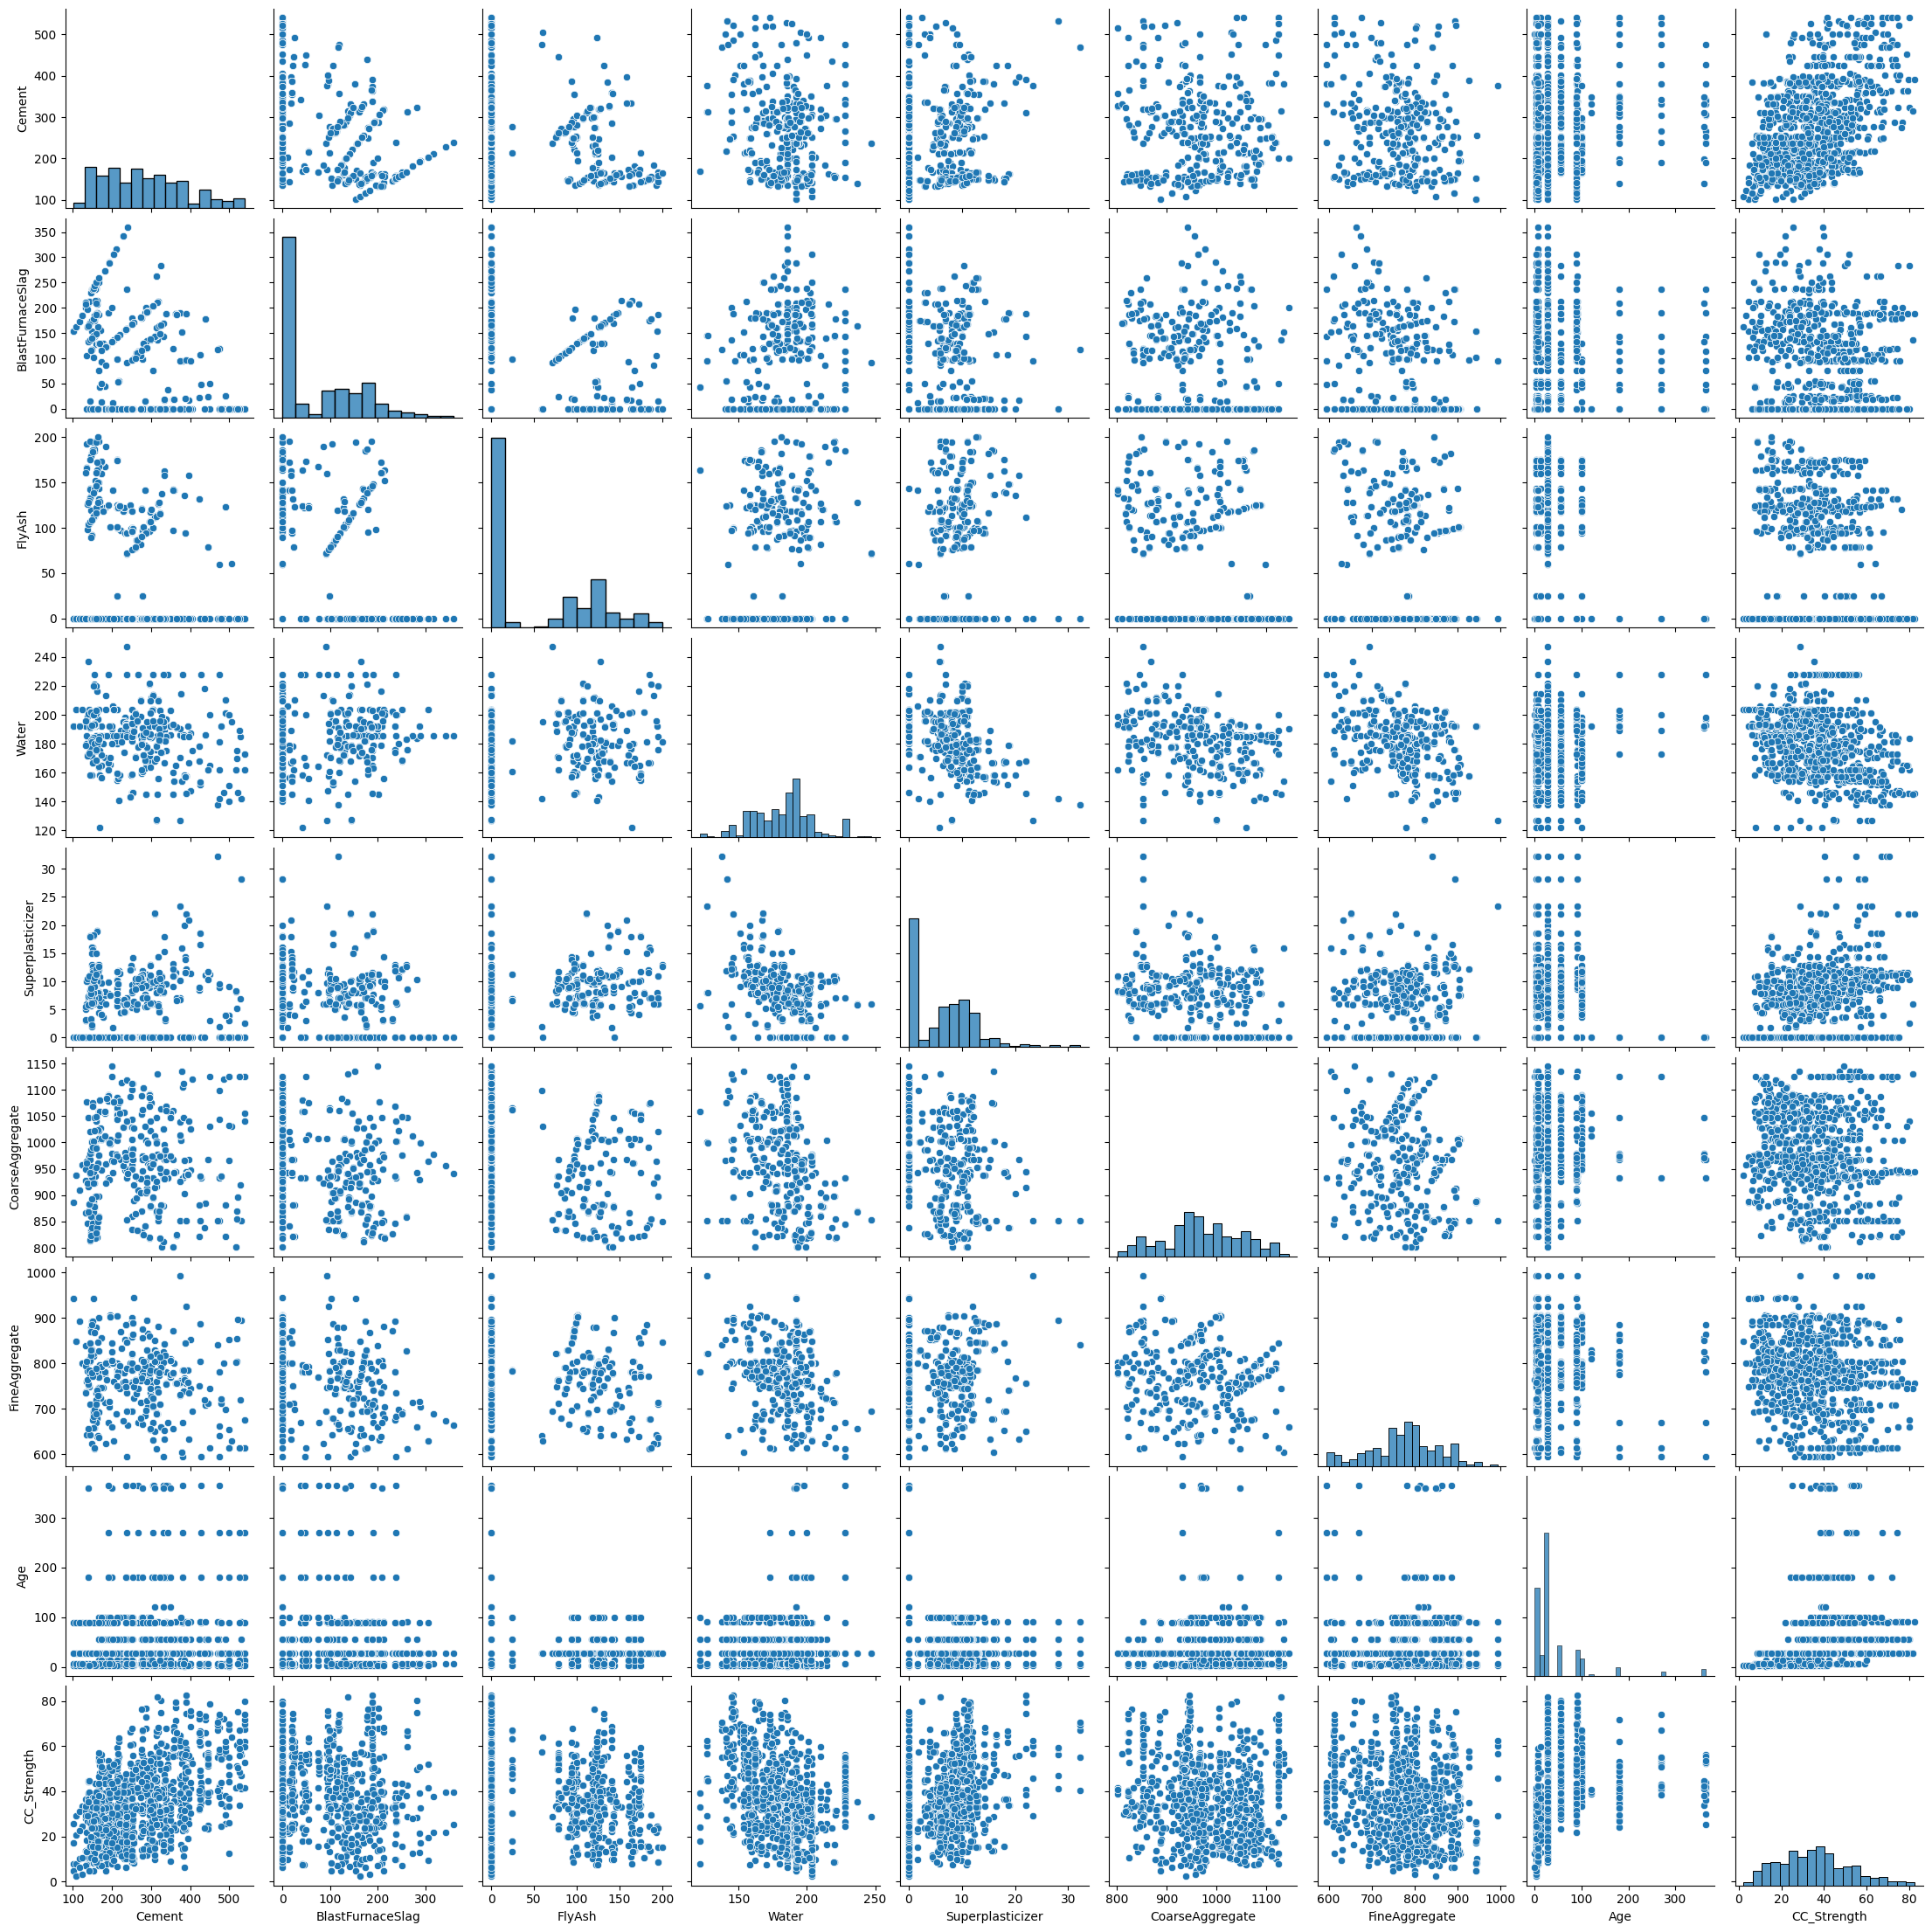

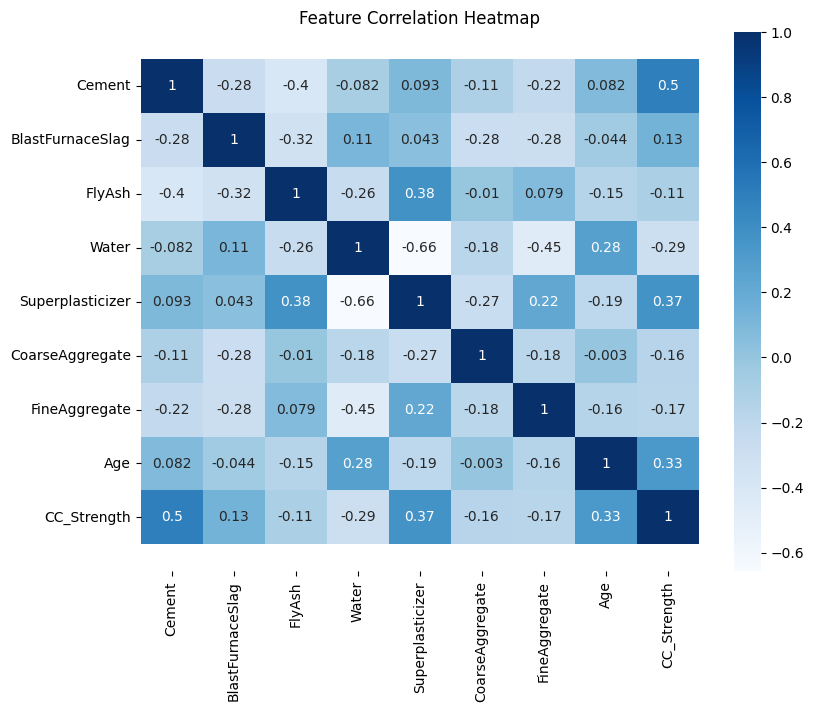

   Cement  BlastFurnaceSlag  FlyAsh  Water  Superplasticizer  CoarseAggregate  \
0   540.0               0.0     0.0  162.0               2.5           1040.0   
1   540.0               0.0     0.0  162.0               2.5           1055.0   
2   332.5             142.5     0.0  228.0               0.0            932.0   
3   332.5             142.5     0.0  228.0               0.0            932.0   
4   198.6             132.4     0.0  192.0               0.0            978.4   

   FineAggregate  Age  
0          676.0   28  
1          676.0   28  
2          594.0  270  
3          594.0  365  
4          825.5  360   

0    79.986111
1    61.887366
2    40.269535
3    41.052780
4    44.296075
Name: CC_Strength, dtype: float64 

Model			 RMSE 		 MSE 		 MAE 		 R2
LinearRegression 	 10.29 		 105.78 	8.23 		0.57
LassoRegression 	 10.29 		 105.78 	8.23 		0.57
RidgeRegression 	 10.29 		 105.78 	8.23 		0.57


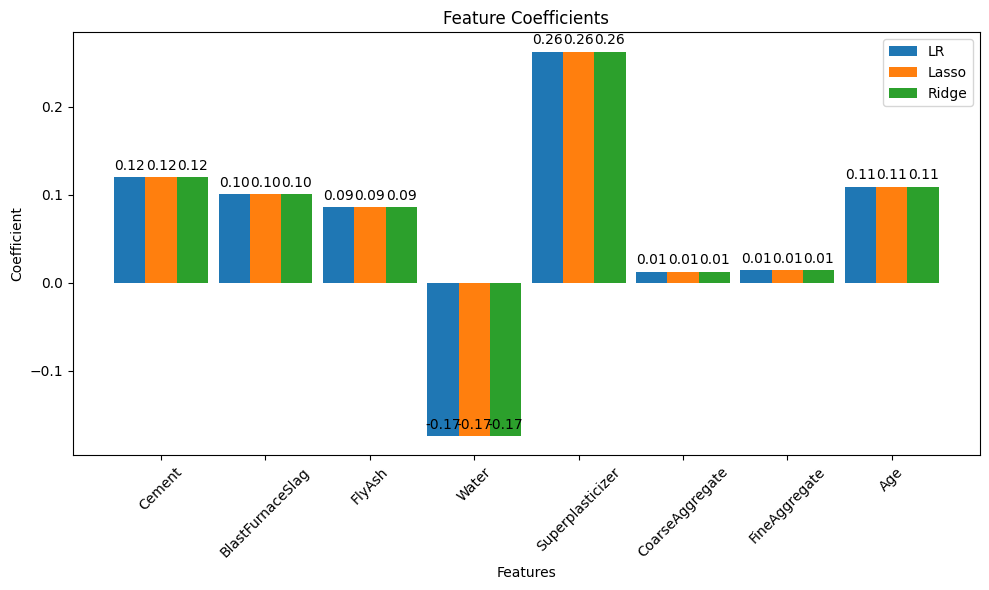

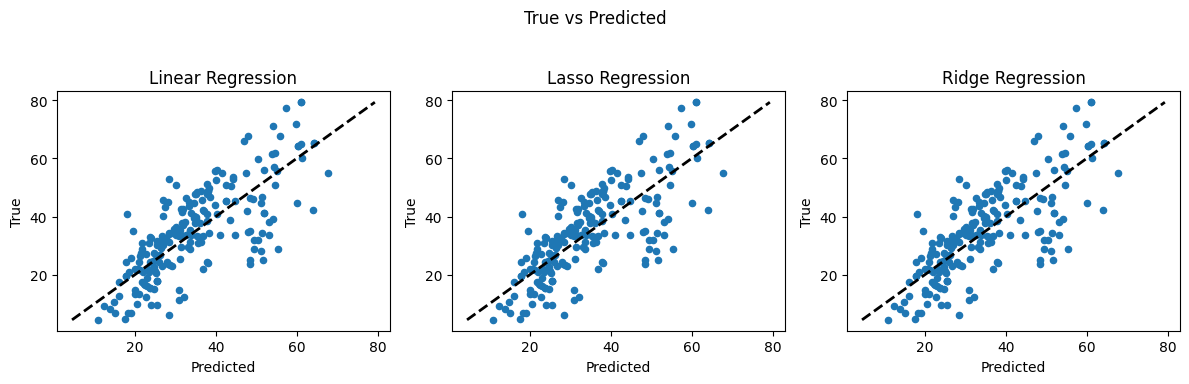

In [169]:
#Get database -- use the Get Data From URL Script
#Step 0: Some controls
pairwise = True
heatmap = True
#Step 1: import needed modules to interact with the internet
import requests
#Step 2: make the connection to the remote file (actually its implementing "bash curl -O http://fqdn/path ...")
remote_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls' # an Excel file
response = requests.get(remote_url) # Gets the file contents puts into an object
output = open('concreteData.xls', 'wb') # Prepare a destination, local
output.write(response.content) # write contents of object to named local file
output.close() # close the connection
# Step 3: Import/install support packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# Step 4: Read the file
data = pd.read_excel("concreteData.xls")
# Step 5: Rename columns (optional but handy - this is not the only method)
req_col_names = ["Cement", "BlastFurnaceSlag", "FlyAsh", "Water", "Superplasticizer",
                 "CoarseAggregate", "FineAggregate", "Age", "CC_Strength"]
curr_col_names = list(data.columns)

mapper = {}
for i, name in enumerate(curr_col_names):
    mapper[name] = req_col_names[i]

data = data.rename(columns=mapper)

print(data.head(),'\n')
# Step 6: Make a pair-wise plot (time consuming but useful)
if pairwise:
    sns.pairplot(data) # This takes awhile
    plt.show()

# Step 7: heatmap of correlations
if heatmap:
    corr = data.corr()
    plt.figure(figsize=(9,7))
    sns.heatmap(corr, annot=True, cmap='Blues')
    b, t = plt.ylim()
    plt.ylim(b+0.5, t-0.5)
    plt.title("Feature Correlation Heatmap")
    plt.show()
# Step 8 Create Target and Features
X = data.iloc[:,:-1]         # Features - All columns but last
y = data.iloc[:,-1]          # Target - Last Column

print(X.head(),'\n')
print(y.head(),'\n')
##################### Portion Below Can Be Modified as Features are Removed ##################
# Step 9 Split Data Set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
# Step 10.  Candidate Models
from sklearn.linear_model import LinearRegression, Lasso, Ridge
# Linear Regression
lr = LinearRegression()
# Lasso Regression
lasso = Lasso(alpha=0.00001) #alpha is the lambda weight close to 0 is ordinary linear regression
# Ridge Regression
ridge = Ridge(alpha=0.00001)  #alpha is the lambda weight close to 0 is ordinary linear regression
# Fitting models on Training data 
lr.fit(X_train, y_train)
lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)
# Making predictions on Test data
y_pred_lr = lr.predict(X_test)
y_pred_lasso = lasso.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
# Report Summary Results
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print("Model\t\t\t RMSE \t\t MSE \t\t MAE \t\t R2")
print("""LinearRegression \t {:.2f} \t\t {:.2f} \t{:.2f} \t\t{:.2f}""".format(
            np.sqrt(mean_squared_error(y_test, y_pred_lr)),mean_squared_error(y_test, y_pred_lr),
            mean_absolute_error(y_test, y_pred_lr), r2_score(y_test, y_pred_lr)))
print("""LassoRegression \t {:.2f} \t\t {:.2f} \t{:.2f} \t\t{:.2f}""".format(
            np.sqrt(mean_squared_error(y_test, y_pred_lasso)),mean_squared_error(y_test, y_pred_lasso),
            mean_absolute_error(y_test, y_pred_lasso), r2_score(y_test, y_pred_lasso)))
print("""RidgeRegression \t {:.2f} \t\t {:.2f} \t{:.2f} \t\t{:.2f}""".format(
            np.sqrt(mean_squared_error(y_test, y_pred_ridge)),mean_squared_error(y_test, y_pred_ridge),
            mean_absolute_error(y_test, y_pred_ridge), r2_score(y_test, y_pred_ridge)))
# Step 11. Prepare some demonstrative plots
coeff_lr = lr.coef_
coeff_lasso = lasso.coef_
coeff_ridge = ridge.coef_
labels = req_col_names[:-1]
x = np.arange(len(labels)) 
width = 0.3
fig, ax = plt.subplots(figsize=(10,6))
rects1 = ax.bar(x - 2*(width/2), coeff_lr,    width, label='LR')
rects2 = ax.bar(x              , coeff_lasso, width, label='Lasso')
rects3 = ax.bar(x + 2*(width/2), coeff_ridge, width, label='Ridge')

ax.set_ylabel('Coefficient')
ax.set_xlabel('Features')
ax.set_title('Feature Coefficients')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{:.2f}'.format(height), xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.show()
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(12,4))

ax1.scatter(y_pred_lr, y_test, s=20)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
ax1.set_ylabel("True")
ax1.set_xlabel("Predicted")
ax1.set_title("Linear Regression")

ax2.scatter(y_pred_lasso, y_test, s=20)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
ax2.set_ylabel("True")
ax2.set_xlabel("Predicted")
ax2.set_title("Lasso Regression")

ax3.scatter(y_pred_ridge, y_test, s=20)
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
ax3.set_ylabel("True")
ax3.set_xlabel("Predicted")
ax3.set_title("Ridge Regression")

fig.suptitle("True vs Predicted")
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
###########################################################

:::{note}
The last row of the pairwise plot is informative it shows the relationship of strength to different proportions of components as well as a distribution of strength. There seems to be no particularly high correlation between independant variables (features). 

This observation can be further confirmed by plotting the Pearson Correlation coefficients between the features. Here we use a heatmap, which will display the correlation coefficient for each variable pair.  A variable is always self-correlated so those values will be 1.0
:::

Now the first pass we observe the prediction plots look the same (because they are), here's why.

:::{admonition} LASSO Regression
*From Wikipedia*

In statistics and machine learning, lasso (least absolute shrinkage and selection operator; also Lasso or LASSO) is a regression analysis method that performs both variable selection and regularization in order to enhance the prediction accuracy and interpretability of the resulting statistical model. It was originally introduced in geophysics, and later by Robert Tibshirani, who coined the term.

Lasso was originally formulated for linear regression models. This simple case reveals a substantial amount about the estimator. These include its relationship to ridge regression and best subset selection and the connections between lasso coefficient estimates and so-called soft thresholding. It also reveals that (like standard linear regression) the coefficient estimates do not need to be unique if covariates are collinear.

Though originally defined for linear regression, lasso regularization is easily extended to other statistical models including generalized linear models, generalized estimating equations, proportional hazards models, and M-estimators. Lasso's ability to perform subset selection relies on the form of the constraint and has a variety of interpretations including in terms of geometry, Bayesian statistics and convex analysis. 

...


In contrast to ridge regression (below), which adds a squared (L2) penalty to the objective function, the LASSO (Least Absolute Shrinkage and Selection Operator) estimator uses an L1 norm penalty, promoting sparsity in the estimated coefficients. This means that some coefficients may be driven exactly to zero---effectively performing automatic feature selection.

Although there is no closed-form matrix solution for LASSO (unlike Ridge), the optimization problem is still convex and can be efficiently solved using coordinate descent or other numerical methods.

The LASSO estimate $\hat{\beta}_L$ is the solution to the following constrained optimization problem:

$$
\hat{\beta}_L = \arg\min_{\beta} \left\{ (\mathbf{y} - \mathbf{X} \beta)^{\mathsf{T}}(\mathbf{y} - \mathbf{X} \beta) + \lambda \sum_{j=1}^{p} |\beta_j| \right\}
$$

where:
- $\mathbf{y}$ is the target vector,
- $\mathbf{X}$ is the design matrix,
- $\beta$ is the coefficient vector,
- $\lambda \geq 0$ is the regularization parameter that controls the strength of the L1 penalty.

Alternatively, LASSO can be expressed as a constrained least squares problem with an L1-norm constraint:

$$
\min_{\beta} \, (\mathbf{y} - \mathbf{X} \beta)^{\mathsf{T}}(\mathbf{y} - \mathbf{X} \beta) \quad \text{subject to} \quad \sum_{j=1}^{p} |\beta_j| \leq t
$$

where $t$ is a constant that determines the maximum allowable size of the coefficient vector in terms of its L1-norm. The Lagrangian form of this problem is:

$$
\min_{\beta} \left\{ (\mathbf{y} - \mathbf{X} \beta)^{\mathsf{T}}(\mathbf{y} - \mathbf{X} \beta) + \lambda \|\beta\|_1 \right\}
$$

Here, the L1 norm $\|\beta\|_1 = \sum_{j=1}^{p} |\beta_j|$ penalizes large and small values alike, encouraging some coefficients to shrink exactly to zero when $\lambda$ is sufficiently large. This sparsity is a key reason for LASSO's popularity in high-dimensional settings and model selection.

As $\lambda \to 0$, the constraint becomes non-binding, and the LASSO estimate tends toward the ordinary least squares solution. As $\lambda \to \infty$, all coefficients shrink toward zero.

[Lasso API notes](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)

Notice in the concrete example above, we specified a small value for $\lambda$ essentially bypassing any regularization (hence identical result to OLS)
:::

:::{admonition} Ridge Regression
*From Wikipedia*

Ridge regression is a method of estimating the coefficients of multiple-regression models in scenarios where the independent variables are highly correlated. It has been used in many fields including econometrics, chemistry, and engineering. Also known as Tikhonov regularization, named for Andrey Tikhonov, it is a method of regularization of ill-posed problems; it is particularly useful to mitigate the problem of multicollinearity in linear regression, which commonly occurs in models with large numbers of parameters. In general, the method provides improved efficiency in parameter estimation problems in exchange for a tolerable amount of bias (see bias–variance tradeoff).

The theory was first introduced by Hoerl and Kennard in 1970 in their Technometrics papers “RIDGE regressions: biased estimation of nonorthogonal problems” and “RIDGE regressions: applications in nonorthogonal problems”. This was the result of ten years of research into the field of ridge analysis.

Ridge regression was developed as a possible solution to the imprecision of least square estimators when linear regression models have some multicollinear (highly correlated) independent variables—by creating a ridge regression estimator (RR). This provides a more precise ridge parameters estimate, as its variance and mean square estimator are often smaller than the least square estimators previously derived.

...

In the simplest case, the problem of a near-singular moment matrix ${\displaystyle (\mathbf {X} ^{\mathsf {T}}\mathbf {X} )}$ is alleviated by adding positive elements to the diagonals, thereby decreasing its condition number. Analogous to the ordinary least squares estimator, the simple ridge estimator is then given by

$${\displaystyle {\hat {\beta }}_{R}=(\mathbf {X} ^{\mathsf {T}}\mathbf {X} +\lambda \mathbf {I} )^{-1}\mathbf {X}^{\mathsf {T}}\mathbf {y} } $$

where $\mathbf {y}$ is the target and, $\mathbf {X}$ is the design matrix, $\mathbf {I}$ is the identity matrix, and the ridge parameter $\lambda \geq 0$ serves as the constant shifting the diagonals of the moment matrix. It can be shown that this estimator is the solution to the least squares problem subject to the constraint ${\displaystyle \beta ^{\mathsf {T}}\beta =c}$, which can be expressed as a Lagrangian:


    
$${\displaystyle \min _{\beta }\,(\mathbf {y} -\mathbf {X} \beta )^{\mathsf {T}}(\mathbf {y} -\mathbf {X} \beta)+\lambda (\beta ^{\mathsf {T}}\beta -c)}$$

which shows that $\lambda$ is nothing but the Lagrange multiplier of the constraint. Typically, $\lambda$ is chosen according to a heuristic criterion, so that the constraint will not be satisfied exactly. Specifically in the case of $\lambda =0$, in which the constraint is non-binding, the ridge estimator reduces to ordinary least squares. 

Alternatively, once a $\lambda$ is selected the remainder is OLS, which is not expensive; so one could simply use a crude grid search to find a suitable value of $\lambda$ that minimizes $${\displaystyle (\mathbf {y} -\mathbf {X} \beta )^{\mathsf {T}}(\mathbf {y} -\mathbf {X} \beta)+\lambda (\beta ^{\mathsf {T}}\beta -c)}$$ taking the OLS solution at each step for the values of $\beta$

In `sklearn` default we have to supply our guess of $\lambda$

[Ridge API notes](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)

In our example above, we set $\lambda$ close to zero, again bypassing the regularization effect, the next block increases $\lambda$ to a useful values to leverage LASSO and RIDGE. 
:::

Model			 RMSE 		 MSE 		 MAE 		 R2
LinearRegression 	 10.29 		 105.78 	8.23 		0.57
LassoRegression 	 10.37 		 107.46 	8.30 		0.56
RidgeRegression 	 10.29 		 105.78 	8.23 		0.57


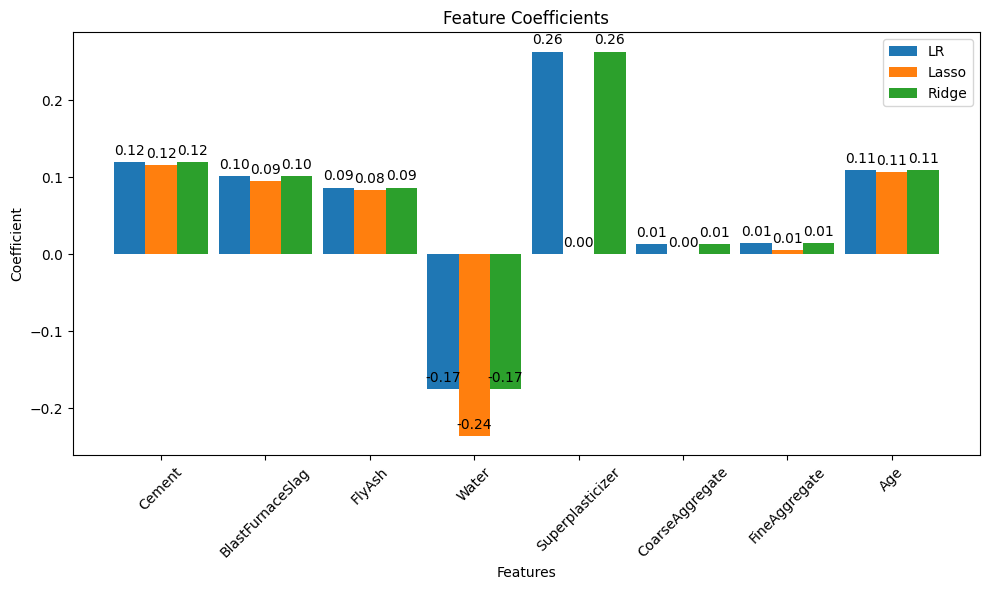

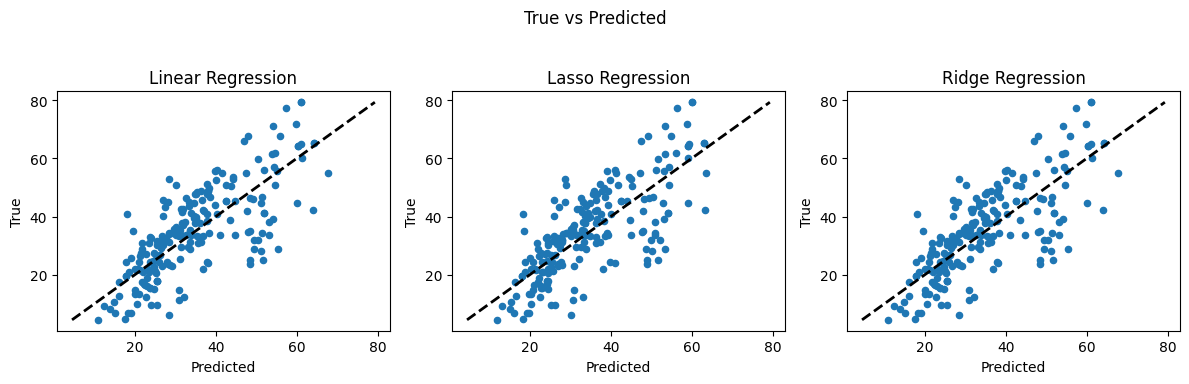

In [170]:
##################### Portion Below Can Be Modified as Features are Removed ##################
# Step 9 Split Data Set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
# Step 10.  Candidate Models
from sklearn.linear_model import LinearRegression, Lasso, Ridge
# Linear Regression
lr = LinearRegression()
# Lasso Regression
lasso = Lasso(alpha=5) #alpha is the lambda weight close to 0 is ordinary linear regression
# Ridge Regression
ridge = Ridge(alpha=5)  #alpha is the lambda weight close to 0 is ordinary linear regression
# Fitting models on Training data 
lr.fit(X_train, y_train)
lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)
# Making predictions on Test data
y_pred_lr = lr.predict(X_test)
y_pred_lasso = lasso.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
# Report Summary Results
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print("Model\t\t\t RMSE \t\t MSE \t\t MAE \t\t R2")
print("""LinearRegression \t {:.2f} \t\t {:.2f} \t{:.2f} \t\t{:.2f}""".format(
            np.sqrt(mean_squared_error(y_test, y_pred_lr)),mean_squared_error(y_test, y_pred_lr),
            mean_absolute_error(y_test, y_pred_lr), r2_score(y_test, y_pred_lr)))
print("""LassoRegression \t {:.2f} \t\t {:.2f} \t{:.2f} \t\t{:.2f}""".format(
            np.sqrt(mean_squared_error(y_test, y_pred_lasso)),mean_squared_error(y_test, y_pred_lasso),
            mean_absolute_error(y_test, y_pred_lasso), r2_score(y_test, y_pred_lasso)))
print("""RidgeRegression \t {:.2f} \t\t {:.2f} \t{:.2f} \t\t{:.2f}""".format(
            np.sqrt(mean_squared_error(y_test, y_pred_ridge)),mean_squared_error(y_test, y_pred_ridge),
            mean_absolute_error(y_test, y_pred_ridge), r2_score(y_test, y_pred_ridge)))
# Step 11. Prepare some demonstrative plots
coeff_lr = lr.coef_
coeff_lasso = lasso.coef_
coeff_ridge = ridge.coef_
labels = req_col_names[:-1]
x = np.arange(len(labels)) 
width = 0.3
fig, ax = plt.subplots(figsize=(10,6))
rects1 = ax.bar(x - 2*(width/2), coeff_lr,    width, label='LR')
rects2 = ax.bar(x              , coeff_lasso, width, label='Lasso')
rects3 = ax.bar(x + 2*(width/2), coeff_ridge, width, label='Ridge')

ax.set_ylabel('Coefficient')
ax.set_xlabel('Features')
ax.set_title('Feature Coefficients')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{:.2f}'.format(height), xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.show()
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(12,4))

ax1.scatter(y_pred_lr, y_test, s=20)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
ax1.set_ylabel("True")
ax1.set_xlabel("Predicted")
ax1.set_title("Linear Regression")

ax2.scatter(y_pred_lasso, y_test, s=20)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
ax2.set_ylabel("True")
ax2.set_xlabel("Predicted")
ax2.set_title("Lasso Regression")

ax3.scatter(y_pred_ridge, y_test, s=20)
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
ax3.set_ylabel("True")
ax3.set_xlabel("Predicted")
ax3.set_title("Ridge Regression")

fig.suptitle("True vs Predicted")
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
###########################################################

The result is meaningful in that LASSO identified 3 features that are worth dropping in the dataset, without much loss of performance. Below is the code to drop the identified features and reanalyze on the reduced set.

   Cement  BlastFurnaceSlag  FlyAsh  Water  Superplasticizer  Age
0   540.0               0.0     0.0  162.0               2.5   28
1   540.0               0.0     0.0  162.0               2.5   28
2   332.5             142.5     0.0  228.0               0.0  270
3   332.5             142.5     0.0  228.0               0.0  365
4   198.6             132.4     0.0  192.0               0.0  360 

0    79.986111
1    61.887366
2    40.269535
3    41.052780
4    44.296075
Name: CC_Strength, dtype: float64
     Cement  BlastFurnaceSlag  FlyAsh   Water  Superplasticizer  Age
128   401.8              94.7    0.00  147.40             11.40   28
365   214.9              53.8  121.89  155.63              9.61   14
480   446.0              24.0   79.00  162.00             11.64    7
814   310.0               0.0    0.00  192.00              0.00  360
169   425.0             106.3    0.00  153.50             16.50   91
Model			 RMSE 		 MSE 		 MAE 		 R2
LinearRegression 	 10.34 		 106.97 	8.30 		0.

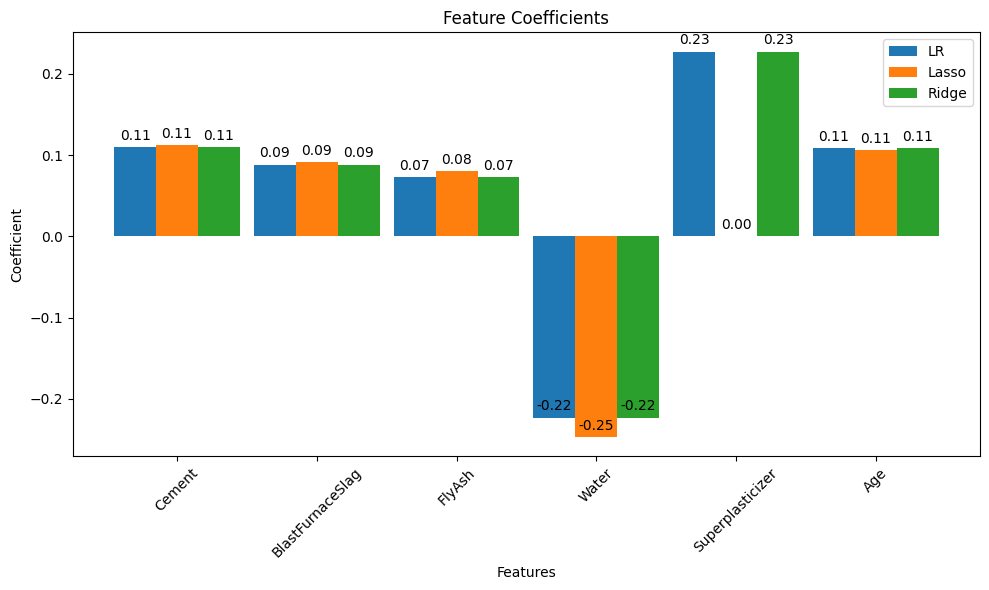

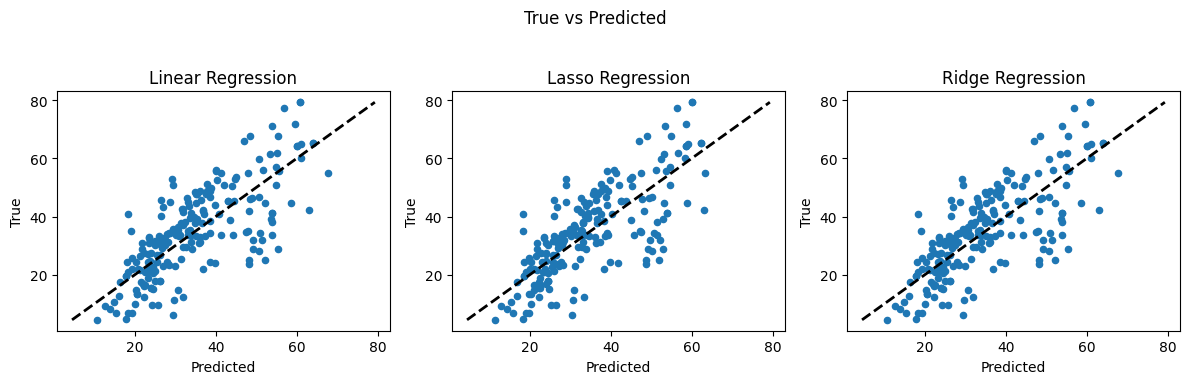

In [171]:
##################### Portion Below Can Be Modified as Features are Removed ##################
#Drop CoarseAggregate and FineAggregate
X = X.drop(columns=["CoarseAggregate", "FineAggregate"], errors='ignore')
labels = X.columns.tolist()
print(X.head(),'\n')
print(y.head())
# Step 9 Split Data Set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
print(X_train.head())
# Step 10.  Candidate Models
from sklearn.linear_model import LinearRegression, Lasso, Ridge
# Linear Regression
lr = LinearRegression()
# Lasso Regression
lasso = Lasso(alpha=5) #alpha is the lambda weight close to 0 is ordinary linear regression
# Ridge Regression
ridge = Ridge(alpha=5)  #alpha is the lambda weight close to 0 is ordinary linear regression
# Fitting models on Training data 
lr.fit(X_train, y_train)
lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)
# Making predictions on Test data
y_pred_lr = lr.predict(X_test)
y_pred_lasso = lasso.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
# Report Summary Results
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print("Model\t\t\t RMSE \t\t MSE \t\t MAE \t\t R2")
print("""LinearRegression \t {:.2f} \t\t {:.2f} \t{:.2f} \t\t{:.2f}""".format(
            np.sqrt(mean_squared_error(y_test, y_pred_lr)),mean_squared_error(y_test, y_pred_lr),
            mean_absolute_error(y_test, y_pred_lr), r2_score(y_test, y_pred_lr)))
print("""LassoRegression \t {:.2f} \t\t {:.2f} \t{:.2f} \t\t{:.2f}""".format(
            np.sqrt(mean_squared_error(y_test, y_pred_lasso)),mean_squared_error(y_test, y_pred_lasso),
            mean_absolute_error(y_test, y_pred_lasso), r2_score(y_test, y_pred_lasso)))
print("""RidgeRegression \t {:.2f} \t\t {:.2f} \t{:.2f} \t\t{:.2f}""".format(
            np.sqrt(mean_squared_error(y_test, y_pred_ridge)),mean_squared_error(y_test, y_pred_ridge),
            mean_absolute_error(y_test, y_pred_ridge), r2_score(y_test, y_pred_ridge)))
# Step 11. Prepare some demonstrative plots
coeff_lr = lr.coef_
coeff_lasso = lasso.coef_
coeff_ridge = ridge.coef_
#labels = req_col_names[:-1]
x = np.arange(len(labels)) 
width = 0.3
fig, ax = plt.subplots(figsize=(10,6))
rects1 = ax.bar(x - 2*(width/2), coeff_lr,    width, label='LR')
rects2 = ax.bar(x              , coeff_lasso, width, label='Lasso')
rects3 = ax.bar(x + 2*(width/2), coeff_ridge, width, label='Ridge')

ax.set_ylabel('Coefficient')
ax.set_xlabel('Features')
ax.set_title('Feature Coefficients')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{:.2f}'.format(height), xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.show()
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(12,4))

ax1.scatter(y_pred_lr, y_test, s=20)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
ax1.set_ylabel("True")
ax1.set_xlabel("Predicted")
ax1.set_title("Linear Regression")

ax2.scatter(y_pred_lasso, y_test, s=20)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
ax2.set_ylabel("True")
ax2.set_xlabel("Predicted")
ax2.set_title("Lasso Regression")

ax3.scatter(y_pred_ridge, y_test, s=20)
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
ax3.set_ylabel("True")
ax3.set_xlabel("Predicted")
ax3.set_title("Ridge Regression")

fig.suptitle("True vs Predicted")
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
###########################################################

Again LASSO suggests dropping one more feature; here is that code block below

   Cement  BlastFurnaceSlag  FlyAsh  Water  Age
0   540.0               0.0     0.0  162.0   28
1   540.0               0.0     0.0  162.0   28
2   332.5             142.5     0.0  228.0  270
3   332.5             142.5     0.0  228.0  365
4   198.6             132.4     0.0  192.0  360 

0    79.986111
1    61.887366
2    40.269535
3    41.052780
4    44.296075
Name: CC_Strength, dtype: float64
     Cement  BlastFurnaceSlag  FlyAsh   Water  Age
128   401.8              94.7    0.00  147.40   28
365   214.9              53.8  121.89  155.63   14
480   446.0              24.0   79.00  162.00    7
814   310.0               0.0    0.00  192.00  360
169   425.0             106.3    0.00  153.50   91
Model			 RMSE 		 MSE 		 MAE 		 R2
LinearRegression 	 10.39 		 108.00 	8.32 		0.56
LassoRegression 	 10.38 		 107.73 	8.32 		0.56
RidgeRegression 	 10.39 		 108.00 	8.32 		0.56


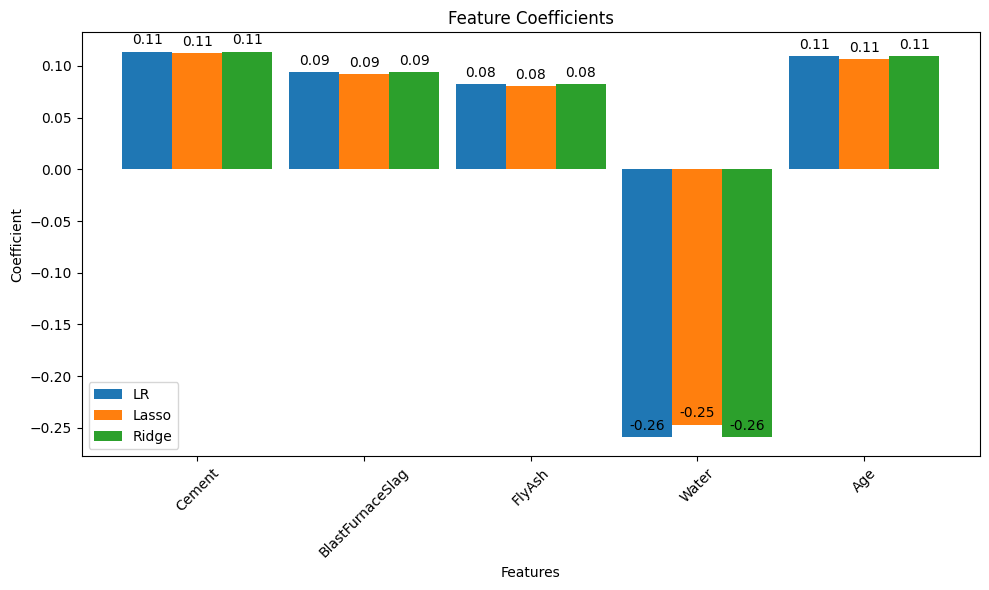

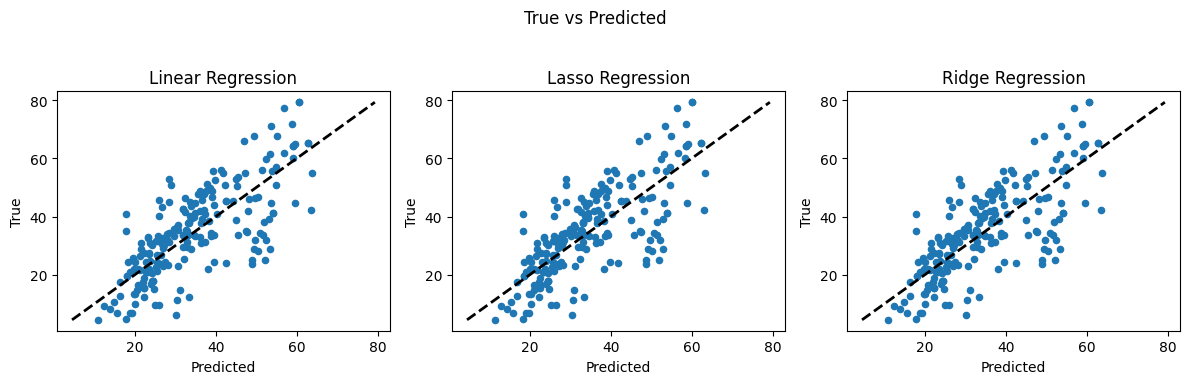

In [172]:
##################### Portion Below Can Be Modified as Features are Removed ##################
#Drop CoarseAggregate and FineAggregate
X = X.drop(columns=["CoarseAggregate", "FineAggregate","Superplasticizer"], errors='ignore')
labels = X.columns.tolist()
print(X.head(),'\n')
print(y.head())
# Step 9 Split Data Set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
print(X_train.head())
# Step 10.  Candidate Models
from sklearn.linear_model import LinearRegression, Lasso, Ridge
# Linear Regression
lr = LinearRegression()
# Lasso Regression
lasso = Lasso(alpha=5) #alpha is the lambda weight close to 0 is ordinary linear regression
# Ridge Regression
ridge = Ridge(alpha=5)  #alpha is the lambda weight close to 0 is ordinary linear regression
# Fitting models on Training data 
lr.fit(X_train, y_train)
lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)
# Making predictions on Test data
y_pred_lr = lr.predict(X_test)
y_pred_lasso = lasso.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
# Report Summary Results
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print("Model\t\t\t RMSE \t\t MSE \t\t MAE \t\t R2")
print("""LinearRegression \t {:.2f} \t\t {:.2f} \t{:.2f} \t\t{:.2f}""".format(
            np.sqrt(mean_squared_error(y_test, y_pred_lr)),mean_squared_error(y_test, y_pred_lr),
            mean_absolute_error(y_test, y_pred_lr), r2_score(y_test, y_pred_lr)))
print("""LassoRegression \t {:.2f} \t\t {:.2f} \t{:.2f} \t\t{:.2f}""".format(
            np.sqrt(mean_squared_error(y_test, y_pred_lasso)),mean_squared_error(y_test, y_pred_lasso),
            mean_absolute_error(y_test, y_pred_lasso), r2_score(y_test, y_pred_lasso)))
print("""RidgeRegression \t {:.2f} \t\t {:.2f} \t{:.2f} \t\t{:.2f}""".format(
            np.sqrt(mean_squared_error(y_test, y_pred_ridge)),mean_squared_error(y_test, y_pred_ridge),
            mean_absolute_error(y_test, y_pred_ridge), r2_score(y_test, y_pred_ridge)))
# Step 11. Prepare some demonstrative plots
coeff_lr = lr.coef_
coeff_lasso = lasso.coef_
coeff_ridge = ridge.coef_
#labels = req_col_names[:-1]
x = np.arange(len(labels)) 
width = 0.3
fig, ax = plt.subplots(figsize=(10,6))
rects1 = ax.bar(x - 2*(width/2), coeff_lr,    width, label='LR')
rects2 = ax.bar(x              , coeff_lasso, width, label='Lasso')
rects3 = ax.bar(x + 2*(width/2), coeff_ridge, width, label='Ridge')

ax.set_ylabel('Coefficient')
ax.set_xlabel('Features')
ax.set_title('Feature Coefficients')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{:.2f}'.format(height), xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.show()
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(12,4))

ax1.scatter(y_pred_lr, y_test, s=20)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
ax1.set_ylabel("True")
ax1.set_xlabel("Predicted")
ax1.set_title("Linear Regression")

ax2.scatter(y_pred_lasso, y_test, s=20)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
ax2.set_ylabel("True")
ax2.set_xlabel("Predicted")
ax2.set_title("Lasso Regression")

ax3.scatter(y_pred_ridge, y_test, s=20)
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
ax3.set_ylabel("True")
ax3.set_xlabel("Predicted")
ax3.set_title("Ridge Regression")

fig.suptitle("True vs Predicted")
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
###########################################################

So these models all have about same weights on the retained features, and these could serve as the basis for the prediction engine for routine use.  That step is left as an exercise.

# 4.3 Weighted Least Squares

Weighted Least Squares is a generalization of ordinary least squares (OLS) regression that addresses the issue of heteroscedasticity---that is, when the variance of the error terms is not constant across observations.

In ordinary least squares, we solve the normal equations:
$$
\begin{equation}
    \mathbf{X}^\mathsf{T} \mathbf{Y} = \mathbf{X}^\mathsf{T} \mathbf{X} \boldsymbol{\beta}
\end{equation}
$$

yielding the well-known solution:

$$\begin{equation}
    \boldsymbol{\beta} = (\mathbf{X}^\mathsf{T} \mathbf{X})^{-1} \mathbf{X}^\mathsf{T} \mathbf{Y}
\end{equation}
$$

If we introduce a diagonal matrix $\mathbf{W}$, containing weights $w_i > 0$ on the diagonal (and zeros elsewhere), we form the weighted version of the normal equations:

$$
\begin{equation}
    \mathbf{X}^\mathsf{T} \mathbf{W} \mathbf{Y} = \mathbf{X}^\mathsf{T} \mathbf{W} \mathbf{X} \boldsymbol{\beta}
\end{equation}
$$

This yields the weighted least squares estimator:

$$
\begin{equation}
    \boldsymbol{\beta}_{\text{WLS}} = (\mathbf{X}^\mathsf{T} \mathbf{W} \mathbf{X})^{-1} \mathbf{X}^\mathsf{T} \mathbf{W} \mathbf{Y}
\end{equation}
$$

This form is similar to OLS but pre-multiplies the design matrix and target vector by a weight matrix $$\mathbf{W}$$, which adjusts the influence of each observation in the regression. Observations with higher weights contribute more to the final estimate.

- If all weights are equal (e.g., \(w_i = 1\)), the model reduces to standard OLS.
- If some weights are large and others small, the regression focuses more on minimizing errors in high-weight observations.
- This is particularly useful when different data points have different levels of reliability, such as repeated measurements with known variances.

Unlike Ridge or LASSO, which penalize the size of coefficients to manage multicollinearity or perform feature selection, WLS reweights the influence of observations based on known or estimated variance.

Summary
- OLS: All observations treated equally.
- WLS: Observations are weighted---often based on known error variances.
- Ridge: Penalizes large coefficients to stabilize solution.
- LASSO: Penalizes the number of active (non-zero) coefficients to encourage simpler models.

[WLS Statsmodel API notes](https://www.statsmodels.org/0.6.1/examples/notebooks/generated/wls.html)

[Weighted Least Squares API notes](https://scipython.com/book/chapter-8-scipy/examples/weighted-and-non-weighted-least-squares-fitting/)

:::{note} 
The code block below performs WLS on the concrete data (after the three features are dropped); and weights are unity -Hence OLS
:::


In [173]:
#WLS Models
from __future__ import print_function
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.sandbox.regression.predstd import wls_prediction_std
from statsmodels.iolib.table import (SimpleTable, default_txt_fmt)

#X is features after columns dropped (optional to drop or restart analysis) 
#y is target

# we need to split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
# now scale the data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
# set the weights
w = np.ones(len(X_train))   # This will be OLS until we change the weights
#w = np.clip(np.random.normal(loc=1.0, scale=0.5, size=len(X_train)), 0.1, 2.0) # Gaussian weights (for demo)
# Now attempt a fit
mod_wls = sm.WLS(y_train, X_train, weights=w)
res_wls = mod_wls.fit()
print(res_wls.summary())

from sklearn.metrics import mean_squared_error

# MSE on training set
mse_train = mean_squared_error(y_train, res_wls.fittedvalues)
print("Training MSE:", mse_train)

                                 WLS Regression Results                                
Dep. Variable:            CC_Strength   R-squared (uncentered):                   0.113
Model:                            WLS   Adj. R-squared (uncentered):              0.107
Method:                 Least Squares   F-statistic:                              20.80
Date:                Tue, 24 Jun 2025   Prob (F-statistic):                    1.35e-19
Time:                        16:58:07   Log-Likelihood:                         -4154.5
No. Observations:                 824   AIC:                                      8319.
Df Residuals:                     819   BIC:                                      8343.
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [176]:
#WLS Models
from __future__ import print_function
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.sandbox.regression.predstd import wls_prediction_std
from statsmodels.iolib.table import (SimpleTable, default_txt_fmt)

#X is features after columns dropped (optional to drop or restart analysis) 
#y is target

# we need to split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
# now scale the data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
# set the weights
#w = np.ones(len(X_train))   # This will be OLS until we change the weights
w = np.clip(np.random.normal(loc=1.0, scale=0.5, size=len(X_train)), 0.1, 2.0) # Gaussian weights (for demo)
# Now attempt a fit
mod_wls = sm.WLS(y_train, X_train, weights=w)
res_wls = mod_wls.fit()
print(res_wls.summary())

from sklearn.metrics import mean_squared_error

# MSE on training set
mse_train = mean_squared_error(y_train, res_wls.fittedvalues)
print("Training MSE:", mse_train)

                                 WLS Regression Results                                
Dep. Variable:            CC_Strength   R-squared (uncentered):                   0.120
Model:                            WLS   Adj. R-squared (uncentered):              0.114
Method:                 Least Squares   F-statistic:                              22.24
Date:                Tue, 24 Jun 2025   Prob (F-statistic):                    6.01e-21
Time:                        16:59:14   Log-Likelihood:                         -4215.2
No. Observations:                 824   AIC:                                      8440.
Df Residuals:                     819   BIC:                                      8464.
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

## Choosing a Regression Method: When and Why

In regression analysis, different methods offer distinct advantages depending on the size of the problem, the structure of the data, and the goals of the analysis. Below is a summary of when each method is most appropriate:

### Ordinary Least Squares (OLS)
- Use When: The data is well-behaved — no multicollinearity, relatively low noise, and the number of features is much smaller than the number of observations.
- Strengths: Simple, interpretable, and efficient for small-to-medium datasets.
- Limitations: Becomes unstable when features are highly correlated or when the number of features approaches (or exceeds) the number of samples.

### Ridge Regression (L2 Regularization)
- Use When: You have many features and potential multicollinearity among predictors.
- Strengths: Stabilizes coefficient estimates by shrinking them toward zero, improving generalization in presence of noisy or correlated inputs.
- Best For: Problems where all features are likely relevant, but their individual effects need regularization.

### LASSO Regression (L1 Regularization)
- Use When: You suspect that only a few features are truly informative.
- Strengths: Performs automatic feature selection by forcing some coefficients to be exactly zero.
- Best For: High-dimensional datasets (e.g., many more features than samples), or when interpretability and sparsity are important.

### Weighted Least Squares (WLS)
- Use When: Different observations have different variances (i.e., heteroscedasticity).
- Strengths: Improves efficiency by giving less weight to noisy observations and more weight to precise ones.
- Best For: Situations where measurement uncertainty is known or estimated, or when variance depends systematically on the predictor values.

## Strategy for Large or High-Dimensional Problems

For large-scale problems, follow this structured approach:

- Preprocessing & Standardization: Always normalize or standardize features when using Ridge or LASSO.

- Exploratory Subset: Run all models (OLS, Ridge, LASSO, WLS if appropriate) on a subset of the data to benchmark metrics (MSE, R², AIC/BIC, etc.).

- Cross-Validation: Use k-fold cross-validation or train-validation-test splits to tune hyperparameters (e.g., λ in Ridge/LASSO) and prevent overfitting.

- Model Comparison: Compare models based on prediction error, parsimony (number of non-zero coefficients), and interpretability.

- Final Model: Choose the model that balances prediction accuracy with simplicity. For deployment, ensure it generalizes well on unseen data.

